In [4]:
import pandas as pd



In [5]:
# --- Library Dasar ---
import pandas as pd
import numpy as np
import re
import string

# --- Library untuk Pra-pemrosesan Teks Bahasa Indonesia (PENTING) ---
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# --- Library untuk Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud # Tambahan untuk visualisasi kata

# --- Library untuk Machine Learning (sklearn) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV # Tambahan untuk Hyperparameter Tuning
from sklearn.metrics import classification_report, confusion_matrix

# --- Library untuk Menyimpan Model ---
import joblib

# Anda siap untuk memulai!
print("Semua library yang direkomendasikan telah siap.")


Semua library yang direkomendasikan telah siap.


In [22]:
df = pd.read_csv('mobile_jkn_reviews_2020_2025.csv')
df.head()


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,74074911-cab0-4de1-a4b8-4dac7d310738,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,4.12.0,2025-03-30 23:40:35,Hi... Terima kasih atas review dan rating yang...,2025-04-14 09:35:00,4.12.0
1,26501548-2abf-433b-9897-aed2a2eb7d75,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,BPJS di aplikasi sekarang ga ada layanan Konsu...,1,0,4.12.0,2025-03-30 23:27:22,Mohon maaf atas ketidaknyamanannya. Dapat kami...,2025-04-14 09:37:57,4.12.0
2,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hp tidak mendukung padahal urgent,1,0,NaN,2025-03-30 22:08:05,NaN,NaN,NaN
3,b15237ba-3378-4e2b-8622-ac33cfd769cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,okeeee,5,0,4.12.0,2025-03-30 21:41:41,Hi... Terima kasih atas review dan rating yang...,2025-04-14 09:35:04,4.12.0
4,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...,1,0,4.12.0,2025-03-30 21:38:16,Mohon maaf atas ketidaknyamanannya. Pastikan j...,2025-04-14 09:38:23,4.12.0


In [23]:
len(df) #kemudian hitung kembali berapa jumlah data yg didapatkan

166784

In [24]:
df[['at','reviewId', 'score', 'content']].head()  #dari scrapping tsb didapatkan banyak sekali kolom, kemudian kolom" tsb kita filter
                                                        #sehingga didapatkan kolom username, score, at dan content

,at,reviewId,score,content
0,2025-03-30 23:40:35,74074911-cab0-4de1-a4b8-4dac7d310738,5,good
1,2025-03-30 23:27:22,26501548-2abf-433b-9897-aed2a2eb7d75,1,BPJS di aplikasi sekarang ga ada layanan Konsu...
2,2025-03-30 22:08:05,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,1,hp tidak mendukung padahal urgent
3,2025-03-30 21:41:41,b15237ba-3378-4e2b-8622-ac33cfd769cc,5,okeeee
4,2025-03-30 21:38:16,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,1,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...


In [25]:
new_df = df[['at','reviewId', 'score', 'content']]
sorted_df = new_df.sort_values(by='at', ascending=False) #Sort by Newst, change to True if you want to sort by Oldest.
sorted_df.head()

,at,reviewId,score,content
0,2025-03-30 23:40:35,74074911-cab0-4de1-a4b8-4dac7d310738,5,good
1,2025-03-30 23:27:22,26501548-2abf-433b-9897-aed2a2eb7d75,1,BPJS di aplikasi sekarang ga ada layanan Konsu...
2,2025-03-30 22:08:05,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,1,hp tidak mendukung padahal urgent
3,2025-03-30 21:41:41,b15237ba-3378-4e2b-8622-ac33cfd769cc,5,okeeee
4,2025-03-30 21:38:16,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,1,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...


In [26]:
my_df = sorted_df[['at','reviewId', 'score', 'content']] #kemudian kita simpan ke variabel my_df

In [27]:
my_df.head()

,at,reviewId,score,content
0,2025-03-30 23:40:35,74074911-cab0-4de1-a4b8-4dac7d310738,5,good
1,2025-03-30 23:27:22,26501548-2abf-433b-9897-aed2a2eb7d75,1,BPJS di aplikasi sekarang ga ada layanan Konsu...
2,2025-03-30 22:08:05,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,1,hp tidak mendukung padahal urgent
3,2025-03-30 21:41:41,b15237ba-3378-4e2b-8622-ac33cfd769cc,5,okeeee
4,2025-03-30 21:38:16,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,1,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...


In [28]:
def pelabelan(score):
    if score < 3:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    elif score == 4:
        return 'Positif'
    elif score == 5:
        return 'Positif'

# Terapkan fungsi pelabelan ke kolom 'score' dan buat kolom 'Label'
my_df['Label'] = my_df['score'].apply(pelabelan)

# Tampilkan 50 baris pertama
my_df.head(60)


,at,reviewId,score,content,Label
0,2025-03-30 23:40:35,74074911-cab0-4de1-a4b8-4dac7d310738,5,good,Positif
1,2025-03-30 23:27:22,26501548-2abf-433b-9897-aed2a2eb7d75,1,BPJS di aplikasi sekarang ga ada layanan Konsu...,Negatif
2,2025-03-30 22:08:05,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,1,hp tidak mendukung padahal urgent,Negatif
3,2025-03-30 21:41:41,b15237ba-3378-4e2b-8622-ac33cfd769cc,5,okeeee,Positif
4,2025-03-30 21:38:16,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,1,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...,Negatif
5,2025-03-30 21:31:34,f645ae85-b697-43df-8842-e82f3fcf532b,5,sangat membantu,Positif
6,2025-03-30 21:30:06,e82f1ff5-32fd-45ef-9b4b-daa2a1831d92,4,lumayan,Positif
7,2025-03-30 21:13:02,1f5d4cd2-e7e3-43d2-be20-4c11b04a2135,5,sukses mantap,Positif
8,2025-03-30 20:46:35,3c57ba6a-5488-4d8f-8e06-a8a8174c8c7e,1,Aplikasi eror😏,Negatif
9,2025-03-30 20:10:22,5455c5fc-146f-4ef6-b4d8-4f2445292eb6,1,aplikasi pemerintah di indonesia hampir semuan...,Negatif


In [29]:
# info() digunakan untuk menampilkan informasi detail tentang dataframe,
#seperti jumlah baris data, nama-nama kolom berserta jumlah data dan tipe datanya, dan sebagainya.
my_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166784 entries, 0 to 166783
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   at        166784 non-null  object
 1   reviewId  166784 non-null  object
 2   score     166784 non-null  int64 
 3   content   166784 non-null  object
 4   Label     166784 non-null  object
dtypes: int64(1), object(4)
memory usage: 7.6+ MB


In [30]:
my_df['at'] = pd.to_datetime(df['at'], errors='coerce')
print(df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')


In [34]:
my_df.head()

,at,reviewId,score,content,Label
0,2025-03-30 23:40:35,74074911-cab0-4de1-a4b8-4dac7d310738,5,good,Positif
1,2025-03-30 23:27:22,26501548-2abf-433b-9897-aed2a2eb7d75,1,BPJS di aplikasi sekarang ga ada layanan Konsu...,Negatif
2,2025-03-30 22:08:05,9af411c6-6b7c-4a1c-845a-c3dc2b4f9c1d,1,hp tidak mendukung padahal urgent,Negatif
3,2025-03-30 21:41:41,b15237ba-3378-4e2b-8622-ac33cfd769cc,5,okeeee,Positif
4,2025-03-30 21:38:16,cd32ce0d-76fa-4a1f-b99b-ec34191cb784,1,APLIKASI APAAN SIH NYUSAHIN BANGET?! PERKARA M...,Negatif


In [36]:
my_df = my_df[~((my_df['at'].dt.year == 2025) & (my_df['at'].dt.month.isin([4, 5])))]


In [41]:
import pandas as pd

# Load dan pastikan datetime
df = pd.read_csv('hasil_output.csv')
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df = df.dropna(subset=['at'])

# Ambil hanya data sampai Maret 2025
df = df[df['at'] < '2025-04-01']

# Tambahkan kolom Tahun
df['Tahun'] = df['at'].dt.year

# Hitung jumlah data per label per tahun
sentimen_per_tahun = df.groupby(['Tahun', 'Label']).size().unstack(fill_value=0)

# Tampilkan urut dari 2020 ke atas
sentimen_per_tahun = sentimen_per_tahun.sort_index()

# Cetak hasil
print(sentimen_per_tahun)


Label  Negatif  Netral  Positif
Tahun                          
2020     17466    2279     7109
2021     16827    1612     6015
2022     16459    1768    14443
2023     12671    1223    14742
2024     21147    1981    18000
2025      7120     604     5318


In [42]:
import pandas as pd

# 1. Load data yang sudah bersih (hasil dari skrip sebelumnya)
# Pastikan file 'hasil_setelah_dibersihkan.csv' sudah ada.
try:
    df = pd.read_csv("hasil_output.csv")

    # 2. Tentukan jumlah sampel per kelas untuk total ~35.000 data
    # 35.000 / 3 kelas ≈ 11.667
    n = 11667

    # Sampling ulang per kelas dengan jumlah baru
    positif = df[df['Label'] == 'Positif'].sample(n=n, random_state=42)
    negatif = df[df['Label'] == 'Negatif'].sample(n=n, random_state=42)
    netral  = df[df['Label'] == 'Netral'].sample(n=n, random_state=42)

    # 3. Gabungkan & acak (nama variabel diubah agar sesuai)
    df_35000 = pd.concat([positif, negatif, netral], ignore_index=True)
    df_35000 = df_35000.sample(frac=1, random_state=42).reset_index(drop=True)

    # 4. Simpan ke file baru
    df_35000.to_csv("dataset_35000.csv", index=False)

    # 5. Ringkasan (teks dan variabel diperbarui)
    print("✅ Distribusi 35.000 data final:")
    print(df_35000['Label'].value_counts())
    print(f"Total data: {len(df_35000)}")
    print("\nDataset baru telah disimpan ke 'dataset_35000.csv'")

except FileNotFoundError:
    print("Error: File 'hasil_setelah_dibersihkan.csv' tidak ditemukan.")
    print("Pastikan Anda sudah menjalankan skrip pembersihan pertama dan file tersebut ada.")
except ValueError as e:
    print(f"Error saat sampling: {e}")
    print("Ini mungkin terjadi jika salah satu kelas (Positif, Negatif, atau Netral) memiliki data kurang dari 11.667 setelah dibersihkan.")

Error saat sampling: Cannot take a larger sample than population when 'replace=False'
Ini mungkin terjadi jika salah satu kelas (Positif, Negatif, atau Netral) memiliki data kurang dari 11.667 setelah dibersihkan.


In [2]:
# ==============================================================================
# 1. IMPORT LIBRARY YANG DIBUTUHKAN
# ==============================================================================
import pandas as pd
import re
import time
import sys
from IPython.display import display

# ==============================================================================
# 2. KONFIGURASI KAMUS NORMALISASI
# ==============================================================================
# Kamus ini berfungsi untuk mengubah kata-kata tidak baku (slang, singkatan, typo)
# menjadi kata baku dalam Bahasa Indonesia.
REPLACEMENTS_DICT = {
    # --- Singkatan Umum & Typo ---
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'enggak': 'tidak', 'nggak': 'tidak', 'ndak': 'tidak', 'ndk': 'tidak', 'gaada': 'tidak ada',
    'tdk': 'tidak', 'bkn': 'bukan', 'utk': 'untuk', 'dgn': 'dengan', 'krn': 'karena', 'karna': 'karena',
    'bgt': 'banget', 'jg': 'juga', 'aja': 'saja', 'jd': 'jadi', 'jgn': 'jangan', 'aza': 'saja',
    'klo': 'kalau', 'kalo': 'kalau', 'kl': 'kalau', 'knp': 'kenapa', 'gmn': 'bagaimana', 'gimana': 'bagaimana', 'bgmn': 'bagaimana', 'ginana': 'bagaimana',
    'sdh': 'sudah', 'udh': 'sudah', 'blm': 'belum', 'balum': 'belum', 'sblm': 'sebelum', 'blom': 'belum',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'bbrp': 'beberapa', 'brp': 'berapa', 'byk': 'banyak', 'bnyk': 'banyak',
    'tp': 'tapi', 'tpi': 'tapi', 'pdhl': 'padahal',
    'trus': 'terus', 'trs': 'terus', 'bngt': 'banget', 'dpt': 'dapat', 'dr': 'dari',
    'kpd': 'kepada', 'kyk': 'seperti', 'ky': 'seperti', 'nih': 'ini', 'sih': 'sih', 'tuh': 'itu', 'ni': 'ini',
    'dong': 'dong', 'kok': 'kok', 'pake': 'pakai', 'dipake': 'dipakai', 'dipke': 'dipakai', 'dipakeitx': 'dipakai',
    'sm': 'sama', 'ama': 'sama', 'cmn': 'cuma',
    'kpn': 'kapan', 'tlg': 'tolong', 'tlong': 'tolong', 'mnt': 'minta', 'gpp': 'tidak apa-apa', 'donk': 'dong',
    'emg': 'memang', 'sbnrnya': 'sebenarnya', 'tq': 'terima kasih', 'yth': 'yang terhormat', 'sgt': 'sangat', 'stlh': 'setelah',
    'lbih': 'lebih', 'bner': 'benar', 'sgera': 'segera', 'slm': 'salam',
    'itx': 'itu', 'bknnya': 'bukannya', 'tmbh': 'tambah', 'mlh': 'malah',
    'pas': 'saat', 'kmrin': 'kemarin', 'i': 'ini', 'liat': 'lihat', 'libat': 'lihat',
    'masiah': 'masih', 'hancur': 'hancur', 'ancur': 'hancur', 'boro boro': 'boro-boro', 'boro2': 'boro-boro', 'gajelas': 'tidak jelas',
    'notif': 'notifikasi', 'didaftarin': 'didaftarkan', 'bwat': 'buat', 'komen': 'komentar', 'ngabisin': 'menghabiskan',
    'mala': 'malah', 'bredel': 'rusak', 'disaat': 'disaat', 'genting': 'genting', 'masukin': 'memasukkan', 'kocak': '[tertawa]',
    'bikin': 'membuat', 'muak': 'muak', 'sia': 'sia-sia', 'bosen': 'bosan',

    # --- Bahasa Gaul, Kata Ganti & Ekspresi Internet ---
    'aku': 'saya', 'aq': 'saya', 'gw': 'saya', 'gua': 'saya', 'gue': 'saya', 'w': 'saya', 'sy': 'saya', 'sya': 'saya',
    'kamu': 'kamu', 'lo': 'kamu', 'loe': 'kamu', 'lu': 'kamu', 'org': 'orang', 'kau': 'kamu',
    'x': 'kali', 'pe x': 'berkali kali', 'y': 'ya', 'maww': 'mau', 'mw': 'mau', 'af': 'maaf', 'maap': 'maaf', 'maunya': 'maunya',
    'wkwk': '[tertawa]', 'wkwkwk': '[tertawa]', 'hahaha': '[tertawa]', 'hehe': '[tertawa]', 'xixi': '[tertawa]',
    'hiks': '[sedih]', 'huhu': '[sedih]',
    'astaga': 'astaga', 'astaghfirullah': 'astaga', 'naudzubillah': 'naudzubillah',
    'anjim': '[umpatan]', 'anjir': '[umpatan]', 'anjay': '[umpatan]', 'njir': '[umpatan]', 'jir': '[umpatan]',

    # --- Bahasa Daerah (Sunda, Jawa, dll.) ---
    'opo': 'apa', 'iki': 'ini', 'iku': 'itu', 'kui': 'itu',
    'piye': 'bagaimana', 'kepiye': 'bagaimana',
    'angel': 'sulit', 'abot': 'berat', 'rudet': 'rumit',
    'suwe': 'lama', 'suwi': 'lama', 'seabad': 'lama sekali', 'lila': 'lama',
    'meneh': 'lagi', 'wae': 'saja', 'ae': 'saja',
    'jan': 'sungguh', 'tenan': 'benar', 'tenan': 'sungguh',
    'ora': 'tidak', 'ra': 'tidak', 'raiso': 'tidak bisa', 'oraiso': 'tidak bisa', 'g bisa': 'tidak bisa', 'gak bisa': 'tidak bisa', 'gabisa': 'tidak bisa',
    'kabeh': 'semua', 'mbuh': 'tidak tahu', 'mumet': 'pusing',
    'nang': 'di', 'neng': 'di',
    'jancok': '[umpatan]', 'matamu': '[umpatan]', 'cok': '[umpatan]', 'cuk': '[umpatan]', 'nanaon': 'apa-apaan', 'hese': 'sulit', 'kie': 'begini', 'ge': 'juga',
    'opo o': 'apa apa', 'wes': 'sudah', 'isoh': 'bisa', 'iso': 'bisa', 'bsa': 'bisa', 'bari jeung': 'tetapi', 'teu': 'tidak', 'cobaen': 'coba',
    'monggo': 'silakan', 'monggo': 'silakan', 'matur nuwun': 'terima kasih', 'suwun': 'terima kasih', 'asline': 'aslinya', 'nggwe': 'buat',
    'disek': 'dulu', 'sakdurunge': 'sebelumnya', 'bukaen': 'buka', 'koyok': 'seperti',

    # --- Kata Kasar & Umpatan ---
    'dongo': 'bodoh', 'dungu': 'bodoh', 'bego': 'bodoh', 'goblok': 'bodoh', 'gblk': 'bodoh', 'tolol': 'bodoh', 'tlol': 'tolol', 'dongok': 'bodoh',
    'anjing': '[umpatan]', 'anjiing': '[umpatan]', 'asu': '[umpatan]', 'hancok': '[umpatan]', 'anjeng': '[umpatan]',
    'bangsat': '[umpatan]', 'bgst': '[umpatan]', 'biadab': 'biadab',
    'kontol': '[umpatan]', 'memek': '[umpatan]', 'jembut': '[umpatan]', 'kntl': '[umpatan]',
    'tai': 'kotoran', 'taik': 'kotoran', 'taek': 'kotoran', 'kampret': '[umpatan]', 'sial': 'sialan', 'najis': '[umpatan]',
    'babi': '[umpatan]', 'binatang': '[umpatan]', 'bajingan': '[umpatan]', 'sampah': '[sampah]', 'bobrok': 'bobrok', 'kotoran': '[kotoran]', 'buwosok': 'busuk', 'bosok': 'busuk',
    'ngehek': '[umpatan]', 'entut': 'kentut', 'mungak': 'muak',

    # --- Istilah Terkait Aplikasi & Layanan ---
    'apk': 'aplikasi', 'app': 'aplikasi', 'apps': 'aplikasi', 'apliksi': 'aplikasi', 'uplikasinya': 'aplikasinya', 'aplikasinya': 'aplikasinya',
    'eror': 'error', 'erorr': 'error', 'erorrr': 'error', 'ngebug': 'bug',
    'lemot': 'lambat', 'lelet': 'lambat', 'loding': 'loading',
    'update': 'pembaruan', 'updet': 'pembaruan', 'diupdate': 'diperbarui', 'pembaruan': 'pembaruan', 'diperbaharui': 'diperbarui', 'abdet': 'pembaruan',
    'login': 'masuk', 'log in': 'masuk', 'logout': 'keluar', 'log out': 'keluar', 'msuk': 'masuk',
    'register': 'daftar', 'registrasi': 'pendaftaran', 'daptar': 'daftar', 'pndftran': 'pendaftaran', 'didaptar': 'didaftar', 'daftarin': 'daftarkan',
    'verif': 'verifikasi', 'ferivikasi': 'verifikasi', 'perivikasi': 'verifikasi', 'verifikasi': 'verifikasi', 'verivikasi': 'verifikasi', 'blel': 'gagal', 'captcha': 'captcha', 'captca': 'captcha',
    'faskes': 'fasilitas kesehatan', 'faskesnya': 'fasilitas kesehatannya',
    'bpjs': 'bpjs', 'jkn': 'jkn', 'kesehatan': 'kesehatan', 'pasien': 'pasien',
    'cs': 'customer service', 'admin': 'admin', 'operator': 'operator',
    'kartu digital': 'kartu digital', 'kartu fisik': 'kartu fisik', 'kk': 'kartu keluarga', 'ktp': 'kartu tanda penduduk', 'kluarga': 'keluarga',
    'tagihan': 'tagihan', 'iuran': 'iuran', 'premi': 'premi',
    'no hp': 'nomor ponsel', 'nomor hp': 'nomor ponsel', 'no peserta': 'nomor peserta', 'nomer': 'nomor',
    'password': 'password', 'pasword': 'password', 'pssword': 'password', 'asword': 'password',
    'cesar': 'sesar', 'operasi': 'operasi', 'autodebit': 'autodebit', 'nik': 'nik',
    'diklik': 'diklik', 'diklik': 'diklik', 'muncul': 'muncul', 'nungguan': 'menunggu', 'oflline': 'offline', 'offline': 'offline',
    'bulak balek': 'bolak-balik', 'bulak bali': 'bolak-balik',

    # --- Koreksi Typo & Bahasa Umum ---
    'bagusss': 'bagus', 'baguss': 'bagus', 'bgs': 'bagus', 'good': 'bagus', 'gud': 'bagus',
    'jelek': 'jelek', 'jlek': 'jelek', 'jellek': 'jelek', 'jelex': 'jelek', 'bapuk': 'jelek',
    'susah': 'sulit', 'ribet': 'rumit', 'gampang': 'mudah',
    'mantap': 'mantap', 'mntp': 'mantap', 'mantul': 'mantap betul',
    'ok': 'oke', 'okeey': 'oke',
    'makasih': 'terima kasih', 'mksh': 'terima kasih', 'thx': 'terima kasih', 'terimakasih': 'terima kasih',
    'tolongg': 'tolong', 'plis': 'tolong', 'pls': 'tolong',
    'respon': 'respons', 'responnya': 'responsnya',
    'bangettt': 'banget', 'bangett': 'banget', 'bgtt': 'banget',
    'parah': 'parah', 'males': 'malas', 'mager': 'malas gerak',
    'kecewa': 'kecewa', 'kcewa': 'kecewa',
    'bintang': 'bintang', 'bntg': 'bintang', 'nol': 'nol',
    'fungsi': 'fungsi', 'fungsik': 'fungsi', 'guna': 'guna',
    'nyampe': 'sampai', 'sampe': 'sampai', 'dikirim': 'dikirim', 'balesan': 'balasan',
    'jt': 'juta', 'rb': 'ribu', 'th': 'tahun', 'bln': 'bulan', 'wktu': 'waktu', 'ttap': 'tetap',
    'ketrangannya': 'keterangannya', 'pnjelasanya': 'penjelasannya', 'mngeluh': 'mengeluh', 'tambahkn': 'tambahkan', 'angak': 'angka',
    'kedepannya': 'kedepannya', 'dihapus': 'dihapus', 'playstore': 'playstore', 'google': 'google', 'macam': 'seperti',
    'terpakse': 'terpaksa', 'selanjutnya': 'selanjutnya', 'giliran': 'giliran', 'aktif': 'aktif', 'sayang': 'sayang', 'nya': 'nya', 'mikir': 'pikir',
    'miskin': 'miskin', 'rakyat': 'rakyat', 'gaji': 'gaji', 'naik': 'naik', 'boom': '[ekspresi]',
    'korup': 'korupsi', 'mulu': 'terus', 'idih': '[ekspresi]', 'sms': 'sms', 'pulsa': 'pulsa', 'min': 'admin',
    'becus': 'becus', 'klen': 'kalian', 'adeuh': '[ekspresi]', 'ambyar': 'hancur'
}

# ==============================================================================
# 3. FUNGSI-FUNGSI PREPROCESSING
# ==============================================================================

def full_clean_text(text):
    """
    Fungsi untuk menjalankan SEMUA langkah pembersihan:
    case folding, penghapusan tanda baca/angka, dan normalisasi kata.
    """
    # 1. Pastikan input adalah string dan ubah ke huruf kecil
    text = str(text).lower()

    # 2. Ganti semua karakter kecuali huruf dan spasi dengan spasi tunggal.
    #    Ini akan menghapus angka, tanda baca, dan simbol.
    text = re.sub(r'[^a-zA-Z\s\[\]]', ' ', text)

    # 3. Normalisasi slang/typo menggunakan kamus
    words = text.split()
    normalized_words = [REPLACEMENTS_DICT.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    # 4. Hapus huruf yang berulang (misal: "baguuus" -> "bagus")
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
    # 5. Gabungkan token yang sama dan berdekatan (misal: "[umpatan] [umpatan]" -> "[umpatan]")
    text = re.sub(r'(\[\w+\])(\s+\1)+', r'\1', text)

    # 6. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def basic_clean_text(text):
    """
    Fungsi untuk pembersihan dasar: case folding dan hapus tanda baca.
    Angka tidak dihapus di sini sesuai contoh.
    """
    # 1. Pastikan input adalah string dan ubah ke huruf kecil
    text = str(text).lower()
    # 2. Hapus semua karakter kecuali huruf, angka, dan spasi
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # 3. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ==============================================================================
# 4. ALUR KERJA UTAMA (PIPELINE)
# ==============================================================================

def run_cleaning_pipeline(input_filename, output_filename, text_column='content'):
    """
    Menjalankan seluruh alur kerja pembersihan data dengan struktur output baru.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai proses pembersihan untuk file '{input_filename}'...")
        
        # --- LANGKAH 1: MEMUAT DATA ---
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        print(f"✅ Data berhasil dimuat. Jumlah baris awal: {len(df)}")
        
        if text_column not in df.columns:
            print(f"❌ Error: Kolom '{text_column}' tidak ditemukan. Kolom yang ada: {list(df.columns)}")
            sys.exit()

        # --- LANGKAH 2: PREPROCESSING BERTINGKAT ---
        print("\n🔄 Memulai proses preprocessing bertingkat...")

        # 2.1 Buat kolom 'cleaned_text' (Pembersihan Dasar)
        df['cleaned_text'] = df[text_column].apply(basic_clean_text)
        print("   - Kolom 'cleaned_text' dibuat (hanya case folding & hapus tanda baca).")

        # 2.2 Buat kolom 'text_length'
        df['text_length'] = df['cleaned_text'].str.len()
        print("   - Kolom 'text_length' dibuat.")

        # 2.3 Buat kolom 'text_clean' (Pembersihan Penuh & Normalisasi)
        df['text_clean'] = df[text_column].apply(full_clean_text)
        print("   - Kolom 'text_clean' dibuat (pembersihan penuh & normalisasi).")
        
        # --- LANGKAH 3: MEMFILTER DATA ---
        print("\n🔄 Memfilter data berdasarkan kolom 'text_clean'...")
        
        # Hapus duplikat berdasarkan teks yang sudah bersih total
        initial_rows = len(df)
        df.drop_duplicates(subset='text_clean', inplace=True, keep='first')
        print(f"   - Menghapus duplikat... {initial_rows - len(df)} baris duplikat dihapus.")
        
        # Hapus baris yang teksnya menjadi kosong setelah dibersihkan
        initial_rows = len(df)
        df = df[df['text_clean'] != ''].copy()
        print(f"   - Menghapus baris kosong... {initial_rows - len(df)} baris dihapus.")
        
        # Hapus ulasan yang terlalu pendek (kurang dari 3 kata)
        initial_rows = len(df)
        df = df[df['text_clean'].str.split().str.len() >= 3].copy()
        print(f"   - Menghapus ulasan pendek (< 3 kata)... {initial_rows - len(df)} baris dihapus.")
        
        df.reset_index(drop=True, inplace=True)
        
        # --- LANGKAH 4: MENAMPILKAN RINGKASAN & PREVIEW ---
        print(f"\n✅ Proses pembersihan selesai. Jumlah data bersih akhir: {len(df)}")
        
        print("\n📊 Menampilkan 5 baris pertama sebagai perbandingan:")
        pd.set_option('display.max_colwidth', 100)
        preview_cols = [text_column, 'cleaned_text', 'text_clean', 'Label']
        display(df[[col for col in preview_cols if col in df.columns]].head(5))
        
        # --- LANGKAH 5: MENYIMPAN HASIL AKHIR ---
        print(f"\n💾 Menyimpan data bersih ke file '{output_filename}'...")
        # Susun urutan kolom sesuai permintaan
        final_column_order = [
            'at', 'reviewId', 'score', 'content', 'Label', 
            'cleaned_text', 'text_length', 'text_clean'
        ]
        # Pastikan kolom 'content' ada (jika nama kolom input berbeda)
        if text_column != 'content' and text_column in df.columns:
            df.rename(columns={text_column: 'content'}, inplace=True)
            
        # Filter hanya kolom yang ada di DataFrame untuk menghindari error
        final_columns_to_save = [col for col in final_column_order if col in df.columns]
        df[final_columns_to_save].to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        total_time = end_time - start_time
        print(f"\n🎉 Selesai! Data bersih telah disimpan. Total waktu: {time.strftime('%H jam %M menit %S detik', time.gmtime(total_time))}.")

    except FileNotFoundError:
        print(f"❌ Error: File '{input_filename}' tidak ditemukan. Pastikan file berada di folder yang sama.")
    except KeyError as e:
        print(f"❌ Error: Kolom {e} tidak ditemukan dalam file CSV Anda.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")

# ==============================================================================
# 5. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    # --- KONFIGURASI FILE ---
    # Ganti nama file dan nama kolom di bawah ini sesuai kebutuhan Anda
    INPUT_FILE = "hasil_bersih35ribu.csv"
    OUTPUT_FILE = "hasil_cleaning_tahap1_struktur_baru.csv"
    # Berdasarkan screenshot Anda, kolom teks bernama 'content'
    TEXT_COLUMN_NAME = "content"
    
    run_cleaning_pipeline(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE,
        text_column=TEXT_COLUMN_NAME
    )


▶️  Memulai proses pembersihan untuk file 'hasil_bersih35ribu.csv'...
🔄 Memuat data dari 'hasil_bersih35ribu.csv'...
✅ Data berhasil dimuat. Jumlah baris awal: 29580

🔄 Memulai proses preprocessing bertingkat...
   - Kolom 'cleaned_text' dibuat (hanya case folding & hapus tanda baca).
   - Kolom 'text_length' dibuat.
   - Kolom 'text_clean' dibuat (pembersihan penuh & normalisasi).

🔄 Memfilter data berdasarkan kolom 'text_clean'...
   - Menghapus duplikat... 124 baris duplikat dihapus.
   - Menghapus baris kosong... 0 baris dihapus.
   - Menghapus ulasan pendek (< 3 kata)... 124 baris dihapus.

✅ Proses pembersihan selesai. Jumlah data bersih akhir: 29332

📊 Menampilkan 5 baris pertama sebagai perbandingan:


,content,cleaned_text,text_clean,Label
0,"Tolong dong di perbaiki aplikasi nya gakusah banyak update yang penting lancar, ini tiap mau ...",tolong dong di perbaiki aplikasi nya gakusah banyak update yang penting lancar ini tiap mau di g...,tolong dong di perbaiki aplikasi nya gakusah banyak pembaruan yang penting lancar ini tiap mau d...,Negatif
1,DONGOK gabisa verif nomor,dongok gabisa verif nomor,bodoh tidak bisa verifikasi nomor,Negatif
2,Kenapa selalu offline??? dan susah untuk digunakan....dimohon admin untuk di perbaiki apk a🙏🙏🙏,kenapa selalu offline dan susah untuk digunakandimohon admin untuk di perbaiki apk a,kenapa selalu offline dan sulit untuk digunakan dimohon admin untuk di perbaiki aplikasi a,Negatif
3,"Sangat bagus, mudah dan membantu",sangat bagus mudah dan membantu,sangat bagus mudah dan membantu,Positif
4,"Baru download, pas buka di suruh update. Hadeehh",baru download pas buka di suruh update hadeehh,baru download saat buka di suruh pembaruan hadeehh,Netral



💾 Menyimpan data bersih ke file 'hasil_cleaning_tahap1_struktur_baru.csv'...

🎉 Selesai! Data bersih telah disimpan. Total waktu: 00 jam 00 menit 01 detik.


In [3]:

import re
def  clean_text(df, text_field, new_text_field_name):
    my_df[new_text_field_name] = my_df[text_field].str.lower()
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", "", elem))
    # remove numbers
    my_df[new_text_field_name] = my_df[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    return my_df

In [4]:
my_df['text_clean'] = my_df['cleaned_text'].str.lower()
my_df['text_clean']
data_clean = clean_text(my_df, 'cleaned_text', 'text_clean')
data_clean.head(10)

NameError: name 'my_df' is not defined

In [11]:
import pandas as pd
import sys

# ==============================================================================
# 1. KONFIGURASI NAMA FILE
# ==============================================================================
# Nama file input yang akan dibaca
INPUT_FILENAME = "hasil_cleaning_tahap1_struktur_baru.csv"
# Nama file output untuk menyimpan hasil
OUTPUT_FILENAME = "hasil_cleaning_tahap2_final.csv"


# ==============================================================================
# 2. DEFINISI FUNGSI
# ==============================================================================
def advanced_case_folding(text):
    """
    Fungsi untuk mengubah teks menjadi huruf kecil, menghapus spasi di awal/akhir,
    dan merapikan spasi ganda di antara kata.
    """
    # Mengembalikan nilai asli jika data kosong (NaN) untuk menghindari error
    if pd.isna(text):
        return text
    
    # Proses pembersihan
    text = str(text).lower()      # Mengubah ke huruf kecil
    text = text.strip()           # Menghapus spasi di awal & akhir
    text = ' '.join(text.split()) # Menghapus spasi ganda antar kata
    return text


# ==============================================================================
# 3. PROSES UTAMA
# ==============================================================================
try:
    # --- Memuat Data dari CSV ---
    print(f"🔄 Memuat data dari file '{INPUT_FILENAME}'...")
    df = pd.read_csv(INPUT_FILENAME)
    print("✅ Data berhasil dimuat.")

    # --- Menerapkan Case Folding Lanjutan ---
    # Cek apakah kolom 'text_clean' ada di dalam DataFrame
    if 'text_clean' in df.columns:
        print("\n🔄 Menerapkan fungsi 'advanced_case_folding' pada kolom 'text_clean'...")
        
        # Terapkan fungsi ke kolom 'text_clean' dan simpan hasilnya di kolom baru 'text_case_folding'
        # Kolom ini akan berisi versi teks yang paling bersih.
        df['text_case_folding'] = df['text_clean'].apply(advanced_case_folding)
        
        print("✅ Proses case folding lanjutan selesai.")

        # --- Menampilkan Hasil ---
        print("\n📊 Menampilkan 10 baris perbandingan antara sebelum dan sesudah proses:")
        # Mengatur agar lebar kolom bisa terlihat penuh
        pd.set_option('display.max_colwidth', 150)
        # Menampilkan kolom sebelum dan sesudah case folding lanjutan untuk perbandingan
        display_cols = ['content', 'text_clean', 'text_case_folding', 'Label']
        display(df[[col for col in display_cols if col in df.columns]].head(10))
        
        # --- Menyimpan Hasil dengan Struktur Lengkap ---
        print(f"\n💾 Menyimpan hasil akhir ke '{OUTPUT_FILENAME}'...")
        
        # Tentukan urutan kolom yang diinginkan untuk file output
        final_column_order = [
            'at', 'reviewId', 'score', 'content', 'Label', 
            'cleaned_text', 'text_length', 'text_clean', 'text_case_folding'
        ]
        
        # Filter hanya kolom yang ada di DataFrame untuk menghindari error
        columns_to_save = [col for col in final_column_order if col in df.columns]
        
        # Simpan ke CSV dengan urutan kolom yang sudah ditentukan
        df[columns_to_save].to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')
        print(f"🎉 Berhasil disimpan! Struktur file output memiliki kolom: {columns_to_save}")

    else:
        print(f"\n❌ Error: Kolom 'text_clean' tidak ditemukan di dalam file '{INPUT_FILENAME}'.")
        print(f"   Pastikan nama kolom sudah benar. Kolom yang tersedia: {list(df.columns)}")

except FileNotFoundError:
    print(f"❌ Error: File '{INPUT_FILENAME}' tidak ditemukan.")
    print("   Pastikan file tersebut berada di folder yang sama dengan skrip ini.")
except Exception as e:
    print(f"❌ Terjadi kesalahan tak terduga: {e}")


🔄 Memuat data dari file 'hasil_cleaning_tahap1_struktur_baru.csv'...
✅ Data berhasil dimuat.

🔄 Menerapkan fungsi 'advanced_case_folding' pada kolom 'text_clean'...
✅ Proses case folding lanjutan selesai.

📊 Menampilkan 10 baris perbandingan antara sebelum dan sesudah proses:


,content,text_clean,text_case_folding,Label
0,"Tolong dong di perbaiki aplikasi nya gakusah banyak update yang penting lancar, ini tiap mau di gunakan eror mulu",tolong dong di perbaiki aplikasi nya gakusah banyak pembaruan yang penting lancar ini tiap mau di gunakan error terus,tolong dong di perbaiki aplikasi nya gakusah banyak pembaruan yang penting lancar ini tiap mau di gunakan error terus,Negatif
1,DONGOK gabisa verif nomor,bodoh tidak bisa verifikasi nomor,bodoh tidak bisa verifikasi nomor,Negatif
2,Kenapa selalu offline??? dan susah untuk digunakan....dimohon admin untuk di perbaiki apk a🙏🙏🙏,kenapa selalu offline dan sulit untuk digunakan dimohon admin untuk di perbaiki aplikasi a,kenapa selalu offline dan sulit untuk digunakan dimohon admin untuk di perbaiki aplikasi a,Negatif
3,"Sangat bagus, mudah dan membantu",sangat bagus mudah dan membantu,sangat bagus mudah dan membantu,Positif
4,"Baru download, pas buka di suruh update. Hadeehh",baru download saat buka di suruh pembaruan hadeehh,baru download saat buka di suruh pembaruan hadeehh,Netral
5,Alhamdulilah Sedikit Membantu Buat Saya. Terimakasih,alhamdulilah sedikit membantu buat saya terima kasih,alhamdulilah sedikit membantu buat saya terima kasih,Positif
6,JKN sangat membantu dalam.pelayanan kesehatan.,jkn sangat membantu dalam pelayanan kesehatan,jkn sangat membantu dalam pelayanan kesehatan,Positif
7,Mau daftar susah otp sms nya Mohon solusinya min,mau daftar sulit otp sms nya mohon solusinya admin,mau daftar sulit otp sms nya mohon solusinya admin,Netral
8,Minta di update mulu. Gak ada pilihan gak usah update nya,minta di pembaruan terus tidak ada pilihan tidak usah pembaruan nya,minta di pembaruan terus tidak ada pilihan tidak usah pembaruan nya,Netral
9,Trus abgred membosankan.aplikasi sering eror..buang waktu,terus abgred membosankan aplikasi sering error buang waktu,terus abgred membosankan aplikasi sering error buang waktu,Negatif



💾 Menyimpan hasil akhir ke 'hasil_cleaning_tahap2_final.csv'...
🎉 Berhasil disimpan! Struktur file output memiliki kolom: ['at', 'reviewId', 'score', 'content', 'Label', 'cleaned_text', 'text_length', 'text_clean', 'text_case_folding']


In [12]:
import pandas as pd
import sys

# ==============================================================================
# 1. KONFIGURASI NAMA FILE
# ==============================================================================
# Nama file input yang akan dibaca (hasil dari tahap sebelumnya)
INPUT_FILENAME = "hasil_cleaning_tahap2_final.csv"
# Nama file output untuk menyimpan hasil
OUTPUT_FILENAME = "hasil_cleaning_tahap3_tokenized.csv"


# ==============================================================================
# 2. DEFINISI FUNGSI
# ==============================================================================
def tokenize_text(text):
    """
    Memecah teks yang sudah bersih menjadi daftar token (kata).
    Teks input diasumsikan sudah bersih dari tanda baca dan sudah di-case folding.
    """
    if pd.isna(text):
        return [] # Kembalikan list kosong jika inputnya kosong
    return text.split()


# ==============================================================================
# 3. PROSES UTAMA
# ==============================================================================
try:
    # --- Memuat Data dari CSV ---
    print(f"🔄 Memuat data dari file '{INPUT_FILENAME}'...")
    df = pd.read_csv(INPUT_FILENAME)
    # Mengganti nama kolom 'text_final' menjadi 'text_case_folding' jika ada
    if 'text_final' in df.columns:
        df.rename(columns={'text_final': 'text_case_folding'}, inplace=True)
    print("✅ Data berhasil dimuat.")

    # Tentukan nama kolom input untuk tokenisasi
    COLUMN_TO_TOKENIZE = 'text_case_folding'

    # Cek apakah kolom yang akan ditokenisasi ada di dalam DataFrame
    if COLUMN_TO_TOKENIZE in df.columns:
        # --- Tahap Tokenisasi ---
        print(f"\n🔄 Melakukan tokenisasi pada kolom '{COLUMN_TO_TOKENIZE}'...")
        df['tokens'] = df[COLUMN_TO_TOKENIZE].apply(tokenize_text)
        print("✅ Proses tokenisasi selesai.")

        # --- Menampilkan Hasil ---
        print("\n📊 Menampilkan 10 baris perbandingan dengan hasil tokenisasi:")
        pd.set_option('display.max_colwidth', 150)
        # Menampilkan kolom teks bersih, hasil tokenisasi, dan label
        display_cols = [COLUMN_TO_TOKENIZE, 'tokens', 'Label']
        display(df[[col for col in display_cols if col in df.columns]].head(10))
        
        # --- Menyimpan Hasil dengan Struktur Lengkap ---
        print(f"\n💾 Menyimpan hasil akhir ke '{OUTPUT_FILENAME}'...")
        
        # Tentukan urutan kolom yang diinginkan untuk file output
        # Ini adalah semua kolom dari file input ditambah kolom baru 'tokens'
        final_column_order = [
            'at', 'reviewId', 'score', 'content', 'Label', 
            'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 'tokens'
        ]
        
        # Filter hanya kolom yang ada di DataFrame untuk menghindari error
        columns_to_save = [col for col in final_column_order if col in df.columns]
        
        # Simpan ke CSV dengan urutan kolom yang sudah ditentukan
        df[columns_to_save].to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')
        print(f"🎉 Berhasil disimpan! Struktur file output memiliki kolom: {columns_to_save}")

    else:
        print(f"\n❌ Error: Kolom '{COLUMN_TO_TOKENIZE}' tidak ditemukan di dalam file '{INPUT_FILENAME}'.")
        print(f"   Pastikan nama kolom sudah benar. Kolom yang tersedia: {list(df.columns)}")

except FileNotFoundError:
    print(f"❌ Error: File '{INPUT_FILENAME}' tidak ditemukan.")
    print("   Pastikan file tersebut berada di folder yang sama dengan skrip ini.")
except Exception as e:
    print(f"❌ Terjadi kesalahan tak terduga: {e}")


🔄 Memuat data dari file 'hasil_cleaning_tahap2_final.csv'...
✅ Data berhasil dimuat.

🔄 Melakukan tokenisasi pada kolom 'text_case_folding'...
✅ Proses tokenisasi selesai.

📊 Menampilkan 10 baris perbandingan dengan hasil tokenisasi:


,text_case_folding,tokens,Label
0,tolong dong di perbaiki aplikasi nya gakusah banyak pembaruan yang penting lancar ini tiap mau di gunakan error terus,"[tolong, dong, di, perbaiki, aplikasi, nya, gakusah, banyak, pembaruan, yang, penting, lancar, ini, tiap, mau, di, gunakan, error, terus]",Negatif
1,bodoh tidak bisa verifikasi nomor,"[bodoh, tidak, bisa, verifikasi, nomor]",Negatif
2,kenapa selalu offline dan sulit untuk digunakan dimohon admin untuk di perbaiki aplikasi a,"[kenapa, selalu, offline, dan, sulit, untuk, digunakan, dimohon, admin, untuk, di, perbaiki, aplikasi, a]",Negatif
3,sangat bagus mudah dan membantu,"[sangat, bagus, mudah, dan, membantu]",Positif
4,baru download saat buka di suruh pembaruan hadeehh,"[baru, download, saat, buka, di, suruh, pembaruan, hadeehh]",Netral
5,alhamdulilah sedikit membantu buat saya terima kasih,"[alhamdulilah, sedikit, membantu, buat, saya, terima, kasih]",Positif
6,jkn sangat membantu dalam pelayanan kesehatan,"[jkn, sangat, membantu, dalam, pelayanan, kesehatan]",Positif
7,mau daftar sulit otp sms nya mohon solusinya admin,"[mau, daftar, sulit, otp, sms, nya, mohon, solusinya, admin]",Netral
8,minta di pembaruan terus tidak ada pilihan tidak usah pembaruan nya,"[minta, di, pembaruan, terus, tidak, ada, pilihan, tidak, usah, pembaruan, nya]",Netral
9,terus abgred membosankan aplikasi sering error buang waktu,"[terus, abgred, membosankan, aplikasi, sering, error, buang, waktu]",Negatif



💾 Menyimpan hasil akhir ke 'hasil_cleaning_tahap3_tokenized.csv'...
🎉 Berhasil disimpan! Struktur file output memiliki kolom: ['at', 'reviewId', 'score', 'content', 'Label', 'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 'tokens']


In [13]:
import pandas as pd
import sys
from ast import literal_eval

# ==============================================================================
# 1. INSTALASI & IMPORT LIBRARY
# ==============================================================================
# Pastikan Anda sudah menginstal library Sastrawi. Jika belum, jalankan perintah ini di terminal:
# pip install Sastrawi

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ImportError:
    print("❌ Error: Library Sastrawi tidak ditemukan.")
    print("   Silakan instal dengan menjalankan: pip install Sastrawi")
    sys.exit()


# ==============================================================================
# 2. KONFIGURASI NAMA FILE
# ==============================================================================
# Nama file input yang akan dibaca (hasil dari tahap tokenisasi)
INPUT_FILENAME = "hasil_cleaning_tahap3_tokenized.csv"
# Nama file output untuk menyimpan hasil
OUTPUT_FILENAME = "hasil_cleaning_tahap4_stopwords_removed.csv"


# ==============================================================================
# 3. INISIALISASI STOPWORD REMOVER
# ==============================================================================
# Membuat factory
stop_factory = StopWordRemoverFactory()
# Mendapatkan daftar stopword default dari Sastrawi dan mengubahnya menjadi set untuk pencarian cepat
stop_words = set(stop_factory.get_stop_words())

print(f"✅ Stopwords dari Sastrawi berhasil dimuat. Jumlah stopword: {len(stop_words)}")


# ==============================================================================
# 4. DEFINISI FUNGSI
# ==============================================================================
def remove_stopwords(tokens):
    """
    Menghapus stopwords dari sebuah list token menggunakan daftar dari Sastrawi.
    """
    if not isinstance(tokens, list):
        return [] # Kembalikan list kosong jika input bukan list
    # Menggunakan daftar stop_words yang sudah diinisialisasi di atas
    return [token for token in tokens if token not in stop_words]


# ==============================================================================
# 5. PROSES UTAMA
# ==============================================================================
try:
    # --- Memuat Data dari CSV ---
    print(f"\n🔄 Memuat data dari file '{INPUT_FILENAME}'...")
    df = pd.read_csv(INPUT_FILENAME)
    print("✅ Data berhasil dimuat.")

    # --- Mengubah kolom 'tokens' dari string menjadi list ---
    if 'tokens' in df.columns:
        print("\n🔄 Mengonversi kolom 'tokens' dari string ke list...")
        # Menggunakan literal_eval untuk konversi yang aman
        df['tokens'] = df['tokens'].apply(literal_eval)
        print("✅ Konversi selesai.")

        # --- Tahap Stopword Removal ---
        print("\n🔄 Menghapus stopwords dari kolom 'tokens'...")
        df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)
        print("✅ Proses stopword removal selesai.")

        # --- Menampilkan Hasil ---
        print("\n📊 Menampilkan 10 baris perbandingan dengan hasil stopword removal:")
        pd.set_option('display.max_colwidth', 150)
        # Menampilkan kolom sebelum dan sesudah stopword removal
        display_cols = ['tokens', 'tokens_no_stopwords', 'Label']
        display(df[[col for col in display_cols if col in df.columns]].head(10))
        
        # --- Menyimpan Hasil dengan Struktur Lengkap ---
        print(f"\n💾 Menyimpan hasil akhir ke '{OUTPUT_FILENAME}'...")
        
        # Tentukan urutan kolom yang diinginkan untuk file output
        final_column_order = [
            'at', 'reviewId', 'score', 'content', 'Label', 
            'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 
            'tokens', 'tokens_no_stopwords'
        ]
        
        # Filter hanya kolom yang ada di DataFrame untuk menghindari error
        columns_to_save = [col for col in final_column_order if col in df.columns]
        
        # Simpan ke CSV dengan urutan kolom yang sudah ditentukan
        df[columns_to_save].to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')
        print(f"🎉 Berhasil disimpan! Struktur file output memiliki kolom: {columns_to_save}")

    else:
        print(f"\n❌ Error: Kolom 'tokens' tidak ditemukan di dalam file '{INPUT_FILENAME}'.")
        print(f"   Pastikan nama kolom sudah benar. Kolom yang tersedia: {list(df.columns)}")

except FileNotFoundError:
    print(f"❌ Error: File '{INPUT_FILENAME}' tidak ditemukan.")
    print("   Pastikan file tersebut berada di folder yang sama dengan skrip ini.")
except Exception as e:
    print(f"❌ Terjadi kesalahan tak terduga: {e}")


✅ Stopwords dari Sastrawi berhasil dimuat. Jumlah stopword: 123

🔄 Memuat data dari file 'hasil_cleaning_tahap3_tokenized.csv'...
✅ Data berhasil dimuat.

🔄 Mengonversi kolom 'tokens' dari string ke list...
✅ Konversi selesai.

🔄 Menghapus stopwords dari kolom 'tokens'...
✅ Proses stopword removal selesai.

📊 Menampilkan 10 baris perbandingan dengan hasil stopword removal:


,tokens,tokens_no_stopwords,Label
0,"[tolong, dong, di, perbaiki, aplikasi, nya, gakusah, banyak, pembaruan, yang, penting, lancar, ini, tiap, mau, di, gunakan, error, terus]","[dong, perbaiki, aplikasi, nya, gakusah, banyak, pembaruan, penting, lancar, tiap, mau, gunakan, error, terus]",Negatif
1,"[bodoh, tidak, bisa, verifikasi, nomor]","[bodoh, verifikasi, nomor]",Negatif
2,"[kenapa, selalu, offline, dan, sulit, untuk, digunakan, dimohon, admin, untuk, di, perbaiki, aplikasi, a]","[selalu, offline, sulit, digunakan, dimohon, admin, perbaiki, aplikasi, a]",Negatif
3,"[sangat, bagus, mudah, dan, membantu]","[sangat, bagus, mudah, membantu]",Positif
4,"[baru, download, saat, buka, di, suruh, pembaruan, hadeehh]","[baru, download, buka, suruh, pembaruan, hadeehh]",Netral
5,"[alhamdulilah, sedikit, membantu, buat, saya, terima, kasih]","[alhamdulilah, sedikit, membantu, buat, terima, kasih]",Positif
6,"[jkn, sangat, membantu, dalam, pelayanan, kesehatan]","[jkn, sangat, membantu, pelayanan, kesehatan]",Positif
7,"[mau, daftar, sulit, otp, sms, nya, mohon, solusinya, admin]","[mau, daftar, sulit, otp, sms, nya, mohon, solusinya, admin]",Netral
8,"[minta, di, pembaruan, terus, tidak, ada, pilihan, tidak, usah, pembaruan, nya]","[minta, pembaruan, terus, pilihan, usah, pembaruan, nya]",Netral
9,"[terus, abgred, membosankan, aplikasi, sering, error, buang, waktu]","[terus, abgred, membosankan, aplikasi, sering, error, buang, waktu]",Negatif



💾 Menyimpan hasil akhir ke 'hasil_cleaning_tahap4_stopwords_removed.csv'...
🎉 Berhasil disimpan! Struktur file output memiliki kolom: ['at', 'reviewId', 'score', 'content', 'Label', 'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 'tokens', 'tokens_no_stopwords']


In [14]:
import pandas as pd
import sys
from ast import literal_eval

# ==============================================================================
# 1. INSTALASI & IMPORT LIBRARY
# ==============================================================================
# Pastikan Anda sudah menginstal library Sastrawi. Jika belum, jalankan perintah ini di terminal:
# pip install Sastrawi

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
except ImportError:
    print("❌ Error: Library Sastrawi tidak ditemukan.")
    print("   Silakan instal dengan menjalankan: pip install Sastrawi")
    sys.exit()


# ==============================================================================
# 2. KONFIGURASI NAMA FILE
# ==============================================================================
# Nama file input yang akan dibaca (hasil dari tahap tokenisasi)
INPUT_FILENAME = "hasil_cleaning_tahap4_stopwords_removed.csv"
# Nama file output untuk menyimpan hasil akhir
OUTPUT_FILENAME = "hasil_cleaning_tahap5_stemmed.csv"


# ==============================================================================
# 3. INISIALISASI PROSESOR TEKS (Sastrawi)
# ==============================================================================
# Inisialisasi Stopword Remover
stop_factory = StopWordRemoverFactory()
stop_words = set(stop_factory.get_stop_words())
print(f"✅ Stopwords dari Sastrawi berhasil dimuat. Jumlah stopword: {len(stop_words)}")

# Inisialisasi Stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()
print("✅ Stemmer dari Sastrawi berhasil dibuat.")


# ==============================================================================
# 4. DEFINISI FUNGSI-FUNGSI
# ==============================================================================
def remove_stopwords(tokens):
    """
    Menghapus stopwords dari sebuah list token menggunakan daftar dari Sastrawi.
    """
    if not isinstance(tokens, list):
        return []
    return [token for token in tokens if token not in stop_words]

def stem_tokens(tokens):
    """
    Melakukan stemming (mengubah kata ke bentuk dasar) pada list token.
    """
    if not isinstance(tokens, list):
        return []
    return [stemmer.stem(word) for word in tokens]


# ==============================================================================
# 5. PROSES UTAMA
# ==============================================================================
try:
    # --- Memuat Data dari CSV ---
    print(f"\n🔄 Memuat data dari file '{INPUT_FILENAME}'...")
    df = pd.read_csv(INPUT_FILENAME)
    print("✅ Data berhasil dimuat.")

    # --- Mengubah kolom 'tokens' dari string menjadi list ---
    if 'tokens' in df.columns:
        print("\n🔄 Mengonversi kolom 'tokens' dari string ke list...")
        df['tokens'] = df['tokens'].apply(literal_eval)
        print("✅ Konversi selesai.")

        # --- Tahap 1: Stopword Removal ---
        print("\n🔄 Menghapus stopwords dari kolom 'tokens'...")
        df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)
        print("✅ Proses stopword removal selesai.")
        
        # --- Tahap 2: Stemming ---
        print("\n🔄 Melakukan stemming pada kolom 'tokens_no_stopwords'...")
        df['stemmed_tokens'] = df['tokens_no_stopwords'].apply(stem_tokens)
        print("✅ Proses stemming selesai.")

        # --- Menampilkan Hasil ---
        print("\n📊 Menampilkan 10 baris perbandingan dengan hasil akhir:")
        pd.set_option('display.max_colwidth', 150)
        # Menampilkan kolom sebelum dan sesudah stemming
        display_cols = ['tokens_no_stopwords', 'stemmed_tokens', 'Label']
        display(df[[col for col in display_cols if col in df.columns]].head(10))
        
        # --- Menyimpan Hasil dengan Struktur Lengkap ---
        print(f"\n💾 Menyimpan hasil akhir ke '{OUTPUT_FILENAME}'...")
        
        # Tentukan urutan kolom yang diinginkan untuk file output
        final_column_order = [
            'at', 'reviewId', 'score', 'content', 'Label', 
            'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 
            'tokens', 'tokens_no_stopwords', 'stemmed_tokens'
        ]
        
        # Filter hanya kolom yang ada di DataFrame untuk menghindari error
        columns_to_save = [col for col in final_column_order if col in df.columns]
        
        # Simpan ke CSV dengan urutan kolom yang sudah ditentukan
        df[columns_to_save].to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')
        print(f"🎉 Berhasil disimpan! Struktur file output memiliki kolom: {columns_to_save}")

    else:
        print(f"\n❌ Error: Kolom 'tokens' tidak ditemukan di dalam file '{INPUT_FILENAME}'.")
        print(f"   Pastikan nama kolom sudah benar. Kolom yang tersedia: {list(df.columns)}")

except FileNotFoundError:
    print(f"❌ Error: File '{INPUT_FILENAME}' tidak ditemukan.")
    print("   Pastikan file tersebut berada di folder yang sama dengan skrip ini.")
except Exception as e:
    print(f"❌ Terjadi kesalahan tak terduga: {e}")


✅ Stopwords dari Sastrawi berhasil dimuat. Jumlah stopword: 123
✅ Stemmer dari Sastrawi berhasil dibuat.

🔄 Memuat data dari file 'hasil_cleaning_tahap4_stopwords_removed.csv'...
✅ Data berhasil dimuat.

🔄 Mengonversi kolom 'tokens' dari string ke list...
✅ Konversi selesai.

🔄 Menghapus stopwords dari kolom 'tokens'...
✅ Proses stopword removal selesai.

🔄 Melakukan stemming pada kolom 'tokens_no_stopwords'...
✅ Proses stemming selesai.

📊 Menampilkan 10 baris perbandingan dengan hasil akhir:


,tokens_no_stopwords,stemmed_tokens,Label
0,"[dong, perbaiki, aplikasi, nya, gakusah, banyak, pembaruan, penting, lancar, tiap, mau, gunakan, error, terus]","[dong, baik, aplikasi, nya, gakusah, banyak, baru, penting, lancar, tiap, mau, guna, error, terus]",Negatif
1,"[bodoh, verifikasi, nomor]","[bodoh, verifikasi, nomor]",Negatif
2,"[selalu, offline, sulit, digunakan, dimohon, admin, perbaiki, aplikasi, a]","[selalu, offline, sulit, guna, mohon, admin, baik, aplikasi, a]",Negatif
3,"[sangat, bagus, mudah, membantu]","[sangat, bagus, mudah, bantu]",Positif
4,"[baru, download, buka, suruh, pembaruan, hadeehh]","[baru, download, buka, suruh, baru, hadeehh]",Netral
5,"[alhamdulilah, sedikit, membantu, buat, terima, kasih]","[alhamdulilah, sedikit, bantu, buat, terima, kasih]",Positif
6,"[jkn, sangat, membantu, pelayanan, kesehatan]","[jkn, sangat, bantu, layan, sehat]",Positif
7,"[mau, daftar, sulit, otp, sms, nya, mohon, solusinya, admin]","[mau, daftar, sulit, otp, sms, nya, mohon, solusi, admin]",Netral
8,"[minta, pembaruan, terus, pilihan, usah, pembaruan, nya]","[minta, baru, terus, pilih, usah, baru, nya]",Netral
9,"[terus, abgred, membosankan, aplikasi, sering, error, buang, waktu]","[terus, abgred, bosan, aplikasi, sering, error, buang, waktu]",Negatif



💾 Menyimpan hasil akhir ke 'hasil_cleaning_tahap5_stemmed.csv'...
🎉 Berhasil disimpan! Struktur file output memiliki kolom: ['at', 'reviewId', 'score', 'content', 'Label', 'cleaned_text', 'text_length', 'text_clean', 'text_case_folding', 'tokens', 'tokens_no_stopwords', 'stemmed_tokens']


In [84]:
import pandas as pd
import sys
import pickle
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer

# ================================
# 1. KONFIGURASI NAMA FILE
# ================================
INPUT_CSV = "hasil_cleaning_tahap5_stemmed.csv"        # Data hasil preprocessing (tokenisasi & stemming)
OUTPUT_TFIDF_MODEL = "tfidf_vectorizer_model.pkl"      # File model TF-IDF
OUTPUT_TFIDF_MATRIX = "tfidf_matrix.pkl"               # File hasil matriks TF-IDF
COLUMN_TEXT = "stemmed_tokens"                         # Nama kolom token hasil preprocessing


# ================================
# 2. PROSES TF-IDF
# ================================
try:
    # --- Memuat Data ---
    print(f"📥 Membaca data dari '{INPUT_CSV}'...")
    df = pd.read_csv(INPUT_CSV)

    # --- Validasi Kolom ---
    if COLUMN_TEXT not in df.columns:
        raise ValueError(f"Kolom '{COLUMN_TEXT}' tidak ditemukan dalam file CSV.")

    # --- Konversi List Token dari String ke Python List ---
    df[COLUMN_TEXT] = df[COLUMN_TEXT].apply(literal_eval)

    # --- Gabungkan Token menjadi Kalimat ---
    df["final_text"] = df[COLUMN_TEXT].apply(lambda tokens: ' '.join(tokens))

    # --- TF-IDF Vectorizer ---
    print("🔄 Membuat dan melatih model TF-IDF...")
    vectorizer = TfidfVectorizer(max_features=5000)
    tfidf_matrix = vectorizer.fit_transform(df["final_text"])

    # --- Menyimpan Model dan Matriks ---
    with open(OUTPUT_TFIDF_MODEL, 'wb') as f_model:
        pickle.dump(vectorizer, f_model)
    with open(OUTPUT_TFIDF_MATRIX, 'wb') as f_matrix:
        pickle.dump(tfidf_matrix, f_matrix)

    # --- Informasi ---
    print("\n✅ TF-IDF selesai.")
    print(f"   - Jumlah dokumen: {tfidf_matrix.shape[0]}")
    print(f"   - Jumlah fitur (kata unik): {tfidf_matrix.shape[1]}")

except FileNotFoundError:
    print(f"❌ File '{INPUT_CSV}' tidak ditemukan.")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")


📥 Membaca data dari 'hasil_cleaning_tahap5_stemmed.csv'...


🔄 Membuat dan melatih model TF-IDF...

✅ TF-IDF selesai.
   - Jumlah dokumen: 29332
   - Jumlah fitur (kata unik): 5000


In [ ]:
import pandas as pd
import pickle
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer

# === File Config ===
INPUT_FILENAME = "hasil_cleaning_tahap5_stemmed.csv"
MODEL_FILENAME = "tfidf_vectorizer_model.pkl"
MATRIX_FILENAME = "tfidf_matrix.pkl"

# === Stopword tambahan untuk filter kata terlalu umum ===
custom_stopwords = [
    "aplikasi", "bpjs", "daftar", "baru", "masuk", "nya", "mohon",
    "nomor", "no", "hp", "verifikasi", "mobile", "jkn", "pakai"
]

try:
    print(f"🔄 Memuat data dari file '{INPUT_FILENAME}'...")
    df = pd.read_csv(INPUT_FILENAME)
    print("✅ Data berhasil dimuat.")

    # Pastikan kolom token ada
    COLUMN = 'stemmed_tokens'
    if COLUMN in df.columns:
        # Konversi string list ke list python
        df[COLUMN] = df[COLUMN].apply(literal_eval)

        # 🔍 Hapus dokumen netral < 5 token
        df = df[~((df['Label'] == "Netral") & (df[COLUMN].apply(len) < 5))].reset_index(drop=True)

        # Gabungkan token jadi string
        df['final_text'] = df[COLUMN].apply(lambda tokens: ' '.join(tokens))

        # TF-IDF vectorizer dengan custom stopwords dan parameter optimal
        print("\n🔄 Melatih TF-IDF dengan filtering & ngram (1,2)...")
        tfidf = TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=10,
            max_df=0.8,
            stop_words=custom_stopwords
        )
        tfidf_matrix = tfidf.fit_transform(df['final_text'])
        print("✅ TF-IDF berhasil dibuat.")

        # Simpan model dan matrix
        with open(MODEL_FILENAME, 'wb') as f:
            pickle.dump(tfidf, f)
        with open(MATRIX_FILENAME, 'wb') as f:
            pickle.dump(tfidf_matrix, f)

        print(f"💾 Disimpan: {MODEL_FILENAME} dan {MATRIX_FILENAME}")
        print("🎯 Siap lanjut ke SMOTE.")

    else:
        print(f"❌ Kolom '{COLUMN}' tidak ditemukan.")

except Exception as e:
    print(f"❌ ERROR: {e}")


🔄 Memuat data dari file 'hasil_cleaning_tahap5_stemmed.csv'...
✅ Data berhasil dimuat.

🔄 Melatih TF-IDF dengan filtering & ngram (1,2)...
✅ TF-IDF berhasil dibuat.
💾 Disimpan: tfidf_vectorizer_model.pkl dan tfidf_matrix.pkl
🎯 Siap lanjut ke SMOTE.


In [ ]:
import pandas as pd
import pickle
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer

# ==============================================================================
# 1. KONFIGURASI (Semua pengaturan ada di sini)
# ==============================================================================
# --- Nama File ---
INPUT_CSV = "hasil_cleaning_tahap5_stemmed.csv"
OUTPUT_TFIDF_MODEL = "tfidf_vectorizer_model.pkl"
OUTPUT_TFIDF_MATRIX = "tfidf_matrix.pkl"
OUTPUT_PROCESSED_DF = "data_for_training.pkl" # Output baru: DataFrame dengan label

# --- Nama Kolom ---
COLUMN_TOKENS = "stemmed_tokens"
COLUMN_LABEL = "Label" # Pastikan nama kolom label Anda benar

# --- Parameter Tuning TF-IDF ---
# Berdasarkan temuan Anda, 10000 adalah yang terbaik. Kita bisa mulai dari sana.
PARAM_MAX_FEATURES = 10000
# Mengabaikan kata yang muncul di kurang dari 5 dokumen (menghapus kata aneh/typo)
PARAM_MIN_DF = 5
# Mengabaikan kata yang muncul di lebih dari 85% dokumen (menghapus kata terlalu umum)
PARAM_MAX_DF = 0.85
# Mengambil kata tunggal dan pasangan kata (bigram), contoh: "tidak bisa"
PARAM_NGRAM_RANGE = (1, 2)

# --- Stopwords Kustom (Sangat Penting untuk Domain Spesifik) ---
# Tambahkan kata-kata umum di data Anda yang tidak membawa sentimen
custom_stopwords = [
    "aplikasi", "bpjs", "jkn", "mobile", "akun", "kartu", "data", "saya",
    "daftar", "masuk", "login", "mohon", "tolong", "buka", "pakai", "nya",
    "nomor", "no", "hp", "ktp", "nik", "verifikasi", "kode", "otp"
]

# ==============================================================================
# 2. FUNGSI UTAMA UNTUK PROSES PEMBOBOTAN
# ==============================================================================
def run_tfidf_weighting():
    """
    Fungsi untuk memuat data, melakukan pembobotan TF-IDF,
    dan menyimpan hasilnya.
    """
    try:
        # --- Memuat Data ---
        print(f"📥 Membaca data dari '{INPUT_CSV}'...")
        df = pd.read_csv(INPUT_CSV)

        # --- Validasi Kolom ---
        if COLUMN_TOKENS not in df.columns:
            raise ValueError(f"Kolom '{COLUMN_TOKENS}' tidak ditemukan.")
        if COLUMN_LABEL not in df.columns:
            raise ValueError(f"Kolom label '{COLUMN_LABEL}' tidak ditemukan.")

        # --- Konversi dan Gabungkan Token ---
        print("🔄 Mengolah token...")
        df[COLUMN_TOKENS] = df[COLUMN_TOKENS].apply(literal_eval)
        df["final_text"] = df[COLUMN_TOKENS].apply(lambda tokens: ' '.join(tokens))

        # --- Inisialisasi TF-IDF Vectorizer dengan Parameter Optimal ---
        print("🛠️  Menginisialisasi TF-IDF Vectorizer dengan parameter cerdas...")
        vectorizer = TfidfVectorizer(
            max_features=PARAM_MAX_FEATURES,
            ngram_range=PARAM_NGRAM_RANGE,
            min_df=PARAM_MIN_DF,
            max_df=PARAM_MAX_DF,
            stop_words=custom_stopwords
        )

        # --- Melatih Model TF-IDF dan Membuat Matriks ---
        print("🏃 Melatih model TF-IDF pada seluruh data...")
        tfidf_matrix = vectorizer.fit_transform(df["final_text"])
        
        # Simpan juga DataFrame yang sudah diproses agar label tetap sinkron
        processed_data = {
            'matrix': tfidf_matrix,
            'labels': df[COLUMN_LABEL]
        }

        # --- Menyimpan Hasil ---
        print("💾 Menyimpan model, matriks, dan data yang telah diproses...")
        with open(OUTPUT_TFIDF_MODEL, 'wb') as f_model:
            pickle.dump(vectorizer, f_model)
        with open(OUTPUT_PROCESSED_DF, 'wb') as f_data:
            pickle.dump(processed_data, f_data)
        # Anda mungkin tidak perlu menyimpan matriks mentah secara terpisah lagi
        # karena sudah ada di dalam 'processed_data'
        # with open(OUTPUT_TFIDF_MATRIX, 'wb') as f_matrix:
        #     pickle.dump(tfidf_matrix, f_matrix)


        # --- Informasi Hasil ---
        print("\n✅ Proses pembobotan TF-IDF selesai!")
        print(f"   - Matriks TF-IDF dibuat dengan shape: {tfidf_matrix.shape[0]} dokumen, {tfidf_matrix.shape[1]} fitur")
        print(f"   - Model TF-IDF disimpan di: '{OUTPUT_TFIDF_MODEL}'")
        print(f"   - Data siap latih (matriks + label) disimpan di: '{OUTPUT_PROCESSED_DF}'")
        print("\n🎯 Anda sekarang bisa lanjut ke tahap 'train_test_split' menggunakan file 'data_for_training.pkl'")

    except FileNotFoundError:
        print(f"❌ ERROR: File '{INPUT_CSV}' tidak ditemukan. Pastikan nama file sudah benar.")
    except Exception as e:
        print(f"❌ ERROR: Terjadi kesalahan tak terduga -> {e}")

# ==============================================================================
# 3. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    run_tfidf_weighting()

In [86]:
import pandas as pd
import pickle
from collections import Counter
from imblearn.over_sampling import SMOTE
import sys

# === Konfigurasi File ===
INPUT_CSV = "hasil_cleaning_tahap5_stemmed.csv"
INPUT_MATRIX = "tfidf_matrix.pkl"
OUTPUT_MATRIX = "balanced_tfidf_matrix.pkl"
OUTPUT_LABELS = "balanced_labels.pkl"

try:
    # 🔄 Load CSV dan hapus netral < 5 token (harus sama persis dengan TF-IDF)
    print(f"🔄 Memuat data dari '{INPUT_CSV}'...")
    df = pd.read_csv(INPUT_CSV)
    df['stemmed_tokens'] = df['stemmed_tokens'].apply(eval)
    df = df[~((df['Label'] == "Netral") & (df['stemmed_tokens'].apply(len) < 5))].reset_index(drop=True)
    labels = df['Label']
    print(f"✅ Data dimuat: {len(labels)} label setelah filter")

    # 🔄 Load TF-IDF Matrix
    print(f"\n🔄 Memuat TF-IDF dari '{INPUT_MATRIX}'...")
    with open(INPUT_MATRIX, 'rb') as f:
        tfidf_matrix = pickle.load(f)
    print(f"✅ TF-IDF dimuat: {tfidf_matrix.shape[0]} baris")

    # ✅ Validasi dimensi
    if tfidf_matrix.shape[0] != len(labels):
        raise ValueError(f"Jumlah baris TF-IDF ({tfidf_matrix.shape[0]}) ≠ jumlah label ({len(labels)})")

    # 📊 Distribusi Awal
    print("\n📊 Distribusi kelas SEBELUM SMOTE:")
    for label, count in Counter(labels).items():
        print(f"   - {label}: {count} data")

    # 🚀 Jalankan SMOTE
    print("\n🔄 Menyeimbangkan data dengan SMOTE...")
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(tfidf_matrix, labels)
    print("✅ SMOTE selesai!")

    # 📊 Distribusi Setelah
    print("\n📊 Distribusi kelas SETELAH SMOTE:")
    for label, count in Counter(y_resampled).items():
        print(f"   - {label}: {count} data")

    # 💾 Simpan Hasil
    with open(OUTPUT_MATRIX, 'wb') as f:
        pickle.dump(X_resampled, f)
    with open(OUTPUT_LABELS, 'wb') as f:
        pickle.dump(y_resampled, f)
    print(f"\n💾 Disimpan: {OUTPUT_MATRIX} dan {OUTPUT_LABELS}")
    print("🎯 Siap lanjut ke Random Forest training.")

except Exception as e:
    print(f"❌ ERROR: {e}")
    sys.exit()


🔄 Memuat data dari 'hasil_cleaning_tahap5_stemmed.csv'...
✅ Data dimuat: 27913 label setelah filter

🔄 Memuat TF-IDF dari 'tfidf_matrix.pkl'...
✅ TF-IDF dimuat: 27913 baris

📊 Distribusi kelas SEBELUM SMOTE:
   - Negatif: 10941 data
   - Positif: 8897 data
   - Netral: 8075 data

🔄 Menyeimbangkan data dengan SMOTE...
✅ SMOTE selesai!

📊 Distribusi kelas SETELAH SMOTE:
   - Negatif: 10941 data
   - Positif: 10941 data
   - Netral: 10941 data

💾 Disimpan: balanced_tfidf_matrix.pkl dan balanced_labels.pkl
🎯 Siap lanjut ke Random Forest training.


🔄 Memuat TF-IDF dari 'balanced_tfidf_matrix.pkl'...
🔄 Memuat Label dari 'balanced_labels.pkl'...

🔄 Membagi data (80% latih / 20% uji)...
✅ Train: (26258, 4358), Test: (6565, 4358)

🔍 Grid Search Random Forest (TF-IDF 10.000 fitur)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
✅ Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 HASIL EVALUASI (TF-IDF 10.000 Fitur)
Akurasi     : 74.20%
Precision   : 74.44%
Recall      : 74.20%
F1-Score    : 74.30%

--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

     Negatif       0.70      0.72      0.71      2188
      Netral       0.67      0.67      0.67      2188
     Positif       0.87      0.83      0.85      2189

    accuracy                           0.74      6565
   macro avg       0.74      0.74      0.74      6565
weighted avg       0.74      0.74      0.74      6565



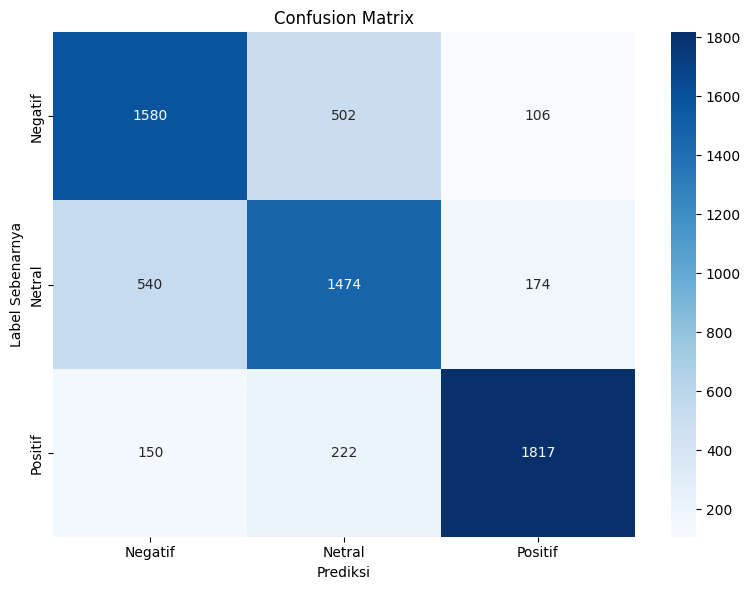


💾 Model Random Forest terbaik disimpan sebagai 'final_random_forest_model.pkl'


In [87]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. LOAD DATA HASIL SMOTE
# ==============================================================================
print("🔄 Memuat TF-IDF dari 'balanced_tfidf_matrix.pkl'...")
with open("balanced_tfidf_matrix.pkl", 'rb') as f:
    X = pickle.load(f)

print("🔄 Memuat Label dari 'balanced_labels.pkl'...")
with open("balanced_labels.pkl", 'rb') as f:
    y = pickle.load(f)

# ==============================================================================
# 2. SPLIT DATA TRAIN-TEST
# ==============================================================================
print("\n🔄 Membagi data (80% latih / 20% uji)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"✅ Train: {X_train.shape}, Test: {X_test.shape}")

# ==============================================================================
# 3. TRAINING DENGAN GRID SEARCH
# ==============================================================================
print("\n🔍 Grid Search Random Forest (TF-IDF 10.000 fitur)...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    bootstrap=True,                  # gunakan bootstrap agar generalisasi lebih baik
    max_features='sqrt'
)

grid_search = GridSearchCV(
    rf, param_grid, cv=3, n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"✅ Best Params: {grid_search.best_params_}")

# ==============================================================================
# 4. PREDIKSI & EVALUASI
# ==============================================================================
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n📊 HASIL EVALUASI (TF-IDF 10.000 Fitur)")
print(f"Akurasi     : {acc:.2%}")
print(f"Precision   : {prec:.2%}")
print(f"Recall      : {rec:.2%}")
print(f"F1-Score    : {f1:.2%}")

print("\n--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_test, y_pred))

# ==============================================================================
# 5. VISUALISASI CONFUSION MATRIX
# ==============================================================================
cm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Netral', 'Positif'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Label Sebenarnya")
plt.tight_layout()
plt.show()

# ==============================================================================
# 6. SIMPAN MODEL
# ==============================================================================
with open("final_random_forest_model.pkl", 'wb') as f:
    pickle.dump(best_model, f)

print("\n💾 Model Random Forest terbaik disimpan sebagai 'final_random_forest_model.pkl'")


In [88]:
import pandas as pd
import pickle
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE  # Pastikan imblearn sudah terinstall

# ==============================================================================
# 1. LOAD DATA ASLI & BUAT FITUR TF-IDF (Dari Skrip 1)
# ==============================================================================
# Muat data asli yang belum di-SMOTE
df = pd.read_csv("hasil_cleaning_tahap5_stemmed.csv")
df['stemmed_tokens'] = df['stemmed_tokens'].apply(literal_eval)

# Filter dan gabungkan token (opsional, sesuaikan dengan strategi Anda)
df = df[~((df['Label'] == "Netral") & (df['stemmed_tokens'].apply(len) < 5))].reset_index(drop=True)
df['final_text'] = df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))

# Inisialisasi TF-IDF Vectorizer (parameter sama seperti sebelumnya)
# Anda bisa bereksperimen dengan max_features di sini
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=10, max_df=0.8)

# Buat matriks TF-IDF dari SELURUH data asli
X_original = tfidf.fit_transform(df['final_text'])
y_original = df['Label']

# ==============================================================================
# 2. SPLIT DATA SEBELUM SMOTE (SANGAT PENTING!)
# ==============================================================================
print("\n🔄 Membagi data ASLI menjadi data latih dan uji (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y_original, test_size=0.2, stratify=y_original, random_state=42
)
print(f"Distribusi kelas di data latih (sebelum SMOTE): \n{y_train.value_counts()}")

# ==============================================================================
# 3. TERAPKAN SMOTE HANYA PADA DATA LATIH
# ==============================================================================
print("\n🔄 Menerapkan SMOTE pada data latih...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Distribusi kelas di data latih (setelah SMOTE): \n{y_train_resampled.value_counts()}")


# ==============================================================================
# 4. TRAINING DENGAN GRID SEARCH (Pada data hasil resample)
# ==============================================================================
print("\n🔍 Memulai Grid Search Random Forest...")
# Gunakan param_grid yang sama atau lebih luas
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# PENTING: Hapus class_weight='balanced' karena Anda sudah menggunakan SMOTE.
# Menggunakan keduanya bisa berlebihan.
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted'
)

# Latih model pada data yang sudah di-SMOTE
grid_search.fit(X_train_resampled, y_train_resampled)

best_model = grid_search.best_estimator_
print(f"✅ Best Params: {grid_search.best_params_}")

# ==============================================================================
# 5. PREDIKSI & EVALUASI (Pada data uji yang ASLI)
# ==============================================================================
print("\n📊 Mengevaluasi model pada data uji yang tidak tersentuh (asli)...")
y_pred = best_model.predict(X_test) # Prediksi pada X_test asli

print(f"\nAkurasi: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

# Tampilkan Confusion Matrix (sama seperti skrip Anda)
# ...


🔄 Membagi data ASLI menjadi data latih dan uji (80/20)...
Distribusi kelas di data latih (sebelum SMOTE): 
Label
Negatif    8753
Positif    7117
Netral     6460
Name: count, dtype: int64

🔄 Menerapkan SMOTE pada data latih...
Distribusi kelas di data latih (setelah SMOTE): 
Label
Negatif    8753
Positif    8753
Netral     8753
Name: count, dtype: int64

🔍 Memulai Grid Search Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

📊 Mengevaluasi model pada data uji yang tidak tersentuh (asli)...

Akurasi: 70.39%

--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

     Negatif       0.68      0.75      0.71      2188
      Netral       0.58      0.52      0.55      1615
     Positif       0.85      0.81      0.83      1780

    accuracy                           0.70      5583
   macro avg       0.70      0.69      0.70   

🔄 Memuat data dari 'hasil_cleaning_tahap5_stemmed.csv'...
✅ Data berhasil dimuat.

📊 Statistik panjang ulasan per kelas:
           count       mean        std  min  25%   50%   75%   max
Label                                                             
Negatif  10941.0  13.698474  10.273314  1.0  6.0  11.0  18.0  80.0
Netral    9494.0  12.698757   9.590864  1.0  6.0  10.0  16.0  69.0
Positif   8897.0   7.517590   6.483580  1.0  4.0   5.0   9.0  90.0

🔎 Top NEGATIF words:
   aplikasi        6475
   masuk           3870
   daftar          3769
   baru            3266
   mau             3057
   nya             3048
   sulit           2454
   terus           2324
   buat            1815
   verifikasi      1730
   udah            1698
   malah           1599
   padahal         1545
   nomor           1443
   hp              1326
   kode            1323
   baik            1210
   pakai           1185
   bpjs            1176
   no              1175

🔎 Top POSITIF words:
   sangat          2

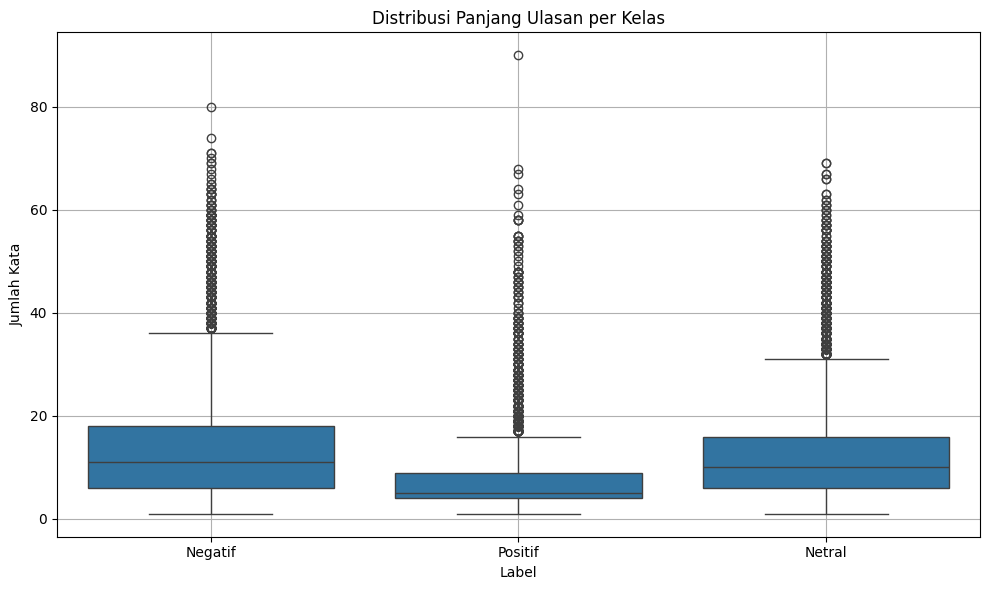

In [54]:
import pandas as pd
from ast import literal_eval
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# 1. LOAD DATASET
# =============================================
FILE_NAME = "hasil_cleaning_tahap5_stemmed.csv"

print(f"🔄 Memuat data dari '{FILE_NAME}'...")
df = pd.read_csv(FILE_NAME)
df['stemmed_tokens'] = df['stemmed_tokens'].apply(literal_eval)
df['final_text'] = df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))
print("✅ Data berhasil dimuat.\n")

# =============================================
# 2. PANJANG ULASAN PER KELAS
# =============================================
df['text_length'] = df['final_text'].apply(lambda x: len(x.split()))
print("📊 Statistik panjang ulasan per kelas:")
print(df.groupby('Label')['text_length'].describe())
print()

# =============================================
# 3. KATA TERBANYAK PER KELAS
# =============================================
def top_words(df, label_name, n=20):
    all_words = df[df['Label'] == label_name]['final_text'].str.cat(sep=' ').split()
    return Counter(all_words).most_common(n)

labels = df['Label'].unique()
for label in labels:
    print(f"🔎 Top {label.upper()} words:")
    top = top_words(df, label)
    for word, freq in top:
        print(f"   {word:<15} {freq}")
    print()

# =============================================
# 4. GRAFIK PANJANG ULASAN
# =============================================
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='text_length', data=df)
plt.title("Distribusi Panjang Ulasan per Kelas")
plt.xlabel("Label")
plt.ylabel("Jumlah Kata")
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import joblib
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Fungsi Pra-pemrosesan Teks ---
# Fungsi ini dijaga tetap sama karena sudah baik.
def handle_negation(text):
    # Menggabungkan kata negasi dengan kata berikutnya, misal: "tidak bagus" -> "tidak_bagus"
    text = re.sub(r'\b(tidak|bukan|jangan|enggak|nggak)\s+(\S+)', r'\1_\2', text)
    return text

def normalize_slang(text, slang_dict):
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# --- ALUR KERJA UTAMA YANG DIMODIFIKASI ---
if __name__ == "__main__":
    try:
        # 1. MEMUAT DAN MEMBERSIHKAN DATA
        print("📥 1. Memuat dan membersihkan dataset...")
        df = pd.read_csv("hasil_bersih35ribu.csv")

        # Pastikan kolom yang dibutuhkan ada
        if 'processed_text' not in df.columns or 'Label' not in df.columns:
            raise KeyError("❌ Kolom 'processed_text' atau 'Label' tidak ditemukan!")

        # Menghapus baris yang kosong dan memastikan tipe data string
        df.dropna(subset=['processed_text', 'Label'], inplace=True)
        df['processed_text'] = df['processed_text'].astype(str)

        # Kamus slang untuk normalisasi
        slang_dictionary = {
            'ga': 'tidak', 'gak': 'tidak', 'bgt': 'banget', 'tp': 'tapi', 'tdk': 'tidak',
            'jg': 'juga', 'yg': 'yang', 'utk': 'untuk', 'skrg': 'sekarang', 'krn': 'karena',
            'makasih': 'terima_kasih', 'thx': 'terima_kasih', 'oke': 'oke', 'sip': 'oke',
            'mantap': 'mantap', 'bgs': 'bagus', 'apps': 'aplikasi', 'byk': 'banyak'
        }

        # Terapkan pra-pemrosesan teks
        df['processed_text'] = df['processed_text'].apply(handle_negation)
        df['processed_text'] = df['processed_text'].apply(lambda x: normalize_slang(x, slang_dictionary))
        
        # Filter ulasan yang terlalu pendek
        df = df[df['processed_text'].apply(lambda x: len(x.split()) >= 3)].reset_index(drop=True)

        print(f"✅ Data siap. Total: {len(df)} baris")

        # Definisikan fitur (X) dan target (y)
        X = df['processed_text']
        y = df['Label']

        # 2. MEMBAGI DATA (SPLIT FIRST!)
        # Ini langkah krusial untuk mencegah kebocoran data.
        print("\n🔀 2. Membagi data menjadi latih dan uji (80:20)...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42,
            stratify=y  # Menjaga proporsi kelas di data latih dan uji
        )

        # 3. VEKTORISASI (TF-IDF)
        # Dilakukan SETELAH membagi data.
        print("\n🔄 3. Membentuk matriks TF-IDF...")
        # Kunci Akurasi: n-gram (1,3) untuk menangkap frasa seperti "tidak_bisa login", "sering error"
        tfidf_vectorizer = TfidfVectorizer(
            ngram_range=(1, 3),   # Menangkap unigram, bigram, dan trigram
            max_features=30000,   # Membatasi jumlah fitur
            min_df=3,             # Mengabaikan kata/frasa yang terlalu jarang
            max_df=0.85           # Mengabaikan kata/frasa yang terlalu sering
        )

        # 'fit_transform' HANYA pada data latih
        X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
        # 'transform' HANYA pada data uji (menggunakan vocabulary dari data latih)
        X_test_tfidf = tfidf_vectorizer.transform(X_test)
        print("✅ Matriks TF-IDF untuk data latih dan uji telah terbentuk.")

        # 4. MENANGANI KETIDAKSEIMBANGAN DATA (OVERSAMPLING)
        # Dilakukan HANYA pada data latih.
        print("\n🔁 4. Menyeimbangkan data latih menggunakan RandomOverSampler...")
        ros = RandomOverSampler(random_state=42)
        X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)
        print(f"✅ Data latih seimbang. Ukuran baru: {X_train_resampled.shape}")

        # 5. TUNING & PELATIHAN MODEL
        print("\n🔧 5. Melatih model Random Forest dengan GridSearchCV...")
        param_grid = {
            'n_estimators': [200, 400],
            'max_depth': [None, 150],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2']
        }

        rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

        # cv=3 untuk proses tuning yang lebih cepat
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, verbose=2, scoring='f1_weighted')
        
        # Latih pada data latih yang sudah seimbang
        grid_search.fit(X_train_resampled, y_train_resampled)
        
        best_rf = grid_search.best_estimator_
        print(f"\n✅ Tuning selesai. Parameter terbaik: {grid_search.best_params_}")

        # 6. EVALUASI MODEL
        print("\n📊 6. Evaluasi model pada data uji (data yang belum pernah dilihat)...")
        # Prediksi pada data uji yang ASLI (tidak di-oversample)
        y_pred = best_rf.predict(X_test_tfidf)

        acc = accuracy_score(y_test, y_pred)
        print(f"Akurasi: {acc:.4f}\n")
        print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

        # 7. SIMPAN MODEL DAN VECTORIZER
        print("\n💾 7. Menyimpan model dan vectorizer...")
        joblib.dump(best_rf, "model_rf_terbaik.pkl")
        joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_terbaik.pkl")
        print("✅ Model dan vectorizer berhasil disimpan.")

    except Exception as e:
        print(f"❌ Terjadi error: {e}")

📥 1. Memuat dan membersihkan dataset...
✅ Data siap. Total: 29566 baris

🔀 2. Membagi data menjadi latih dan uji (80:20)...

🔄 3. Membentuk matriks TF-IDF...
✅ Matriks TF-IDF untuk data latih dan uji telah terbentuk.

🔁 4. Menyeimbangkan data latih menggunakan RandomOverSampler...
✅ Data latih seimbang. Ukuran baru: (26292, 22383)

🔧 5. Melatih model Random Forest dengan GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  44.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  46.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  27.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=400; total time= 1.6min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=400; total time= 1.4min
[CV] END max_depth=None, max_features=sqrt, 

--- Memulai Skrip Analisis Kualitas Data ---
Data hasil pra-pemrosesan berhasil dimuat.

--- Analisis Frekuensi Kata (Top 30 Teratas) ---


C:\Users\lenovo\AppData\Local\Temp\ipykernel_19760\1621595707.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_common_words, palette='viridis')


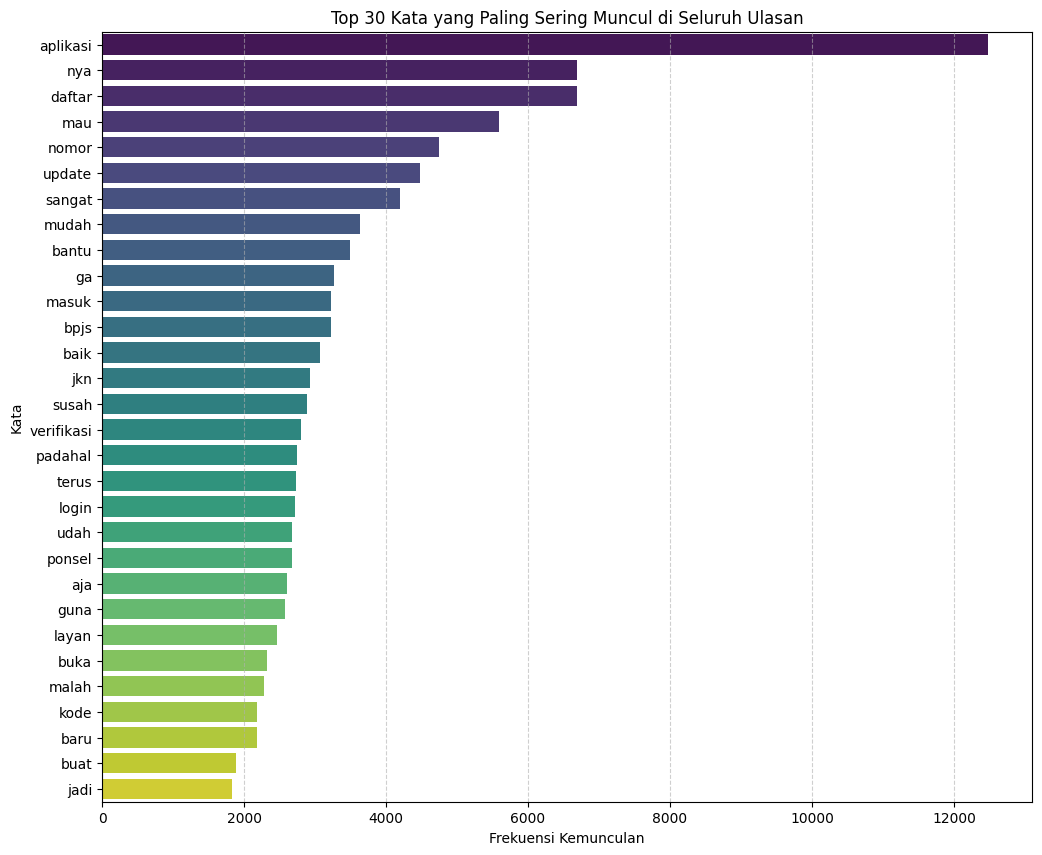


Periksa daftar di atas. Apakah ada stopwords (e.g., 'yg', 'di'), typo, atau kata tidak relevan? Jika ada, data Anda perlu pembersihan lebih lanjut.

--- Analisis Word Cloud per Kategori Sentimen ---


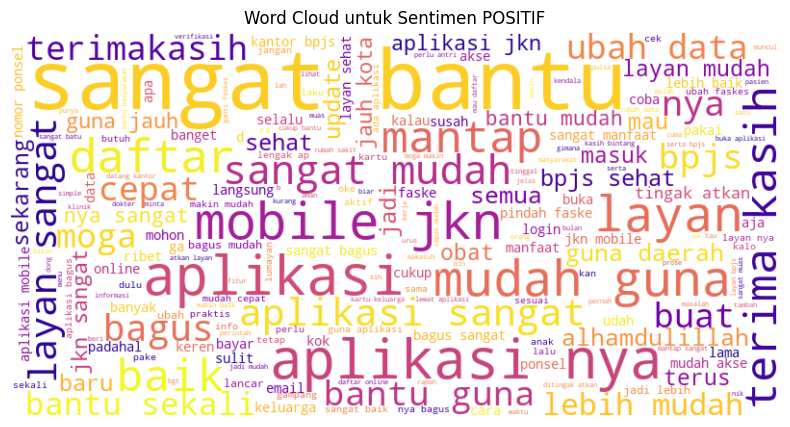

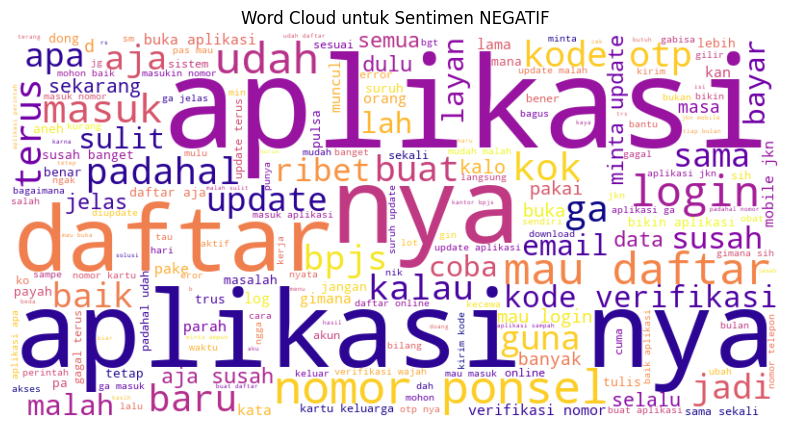

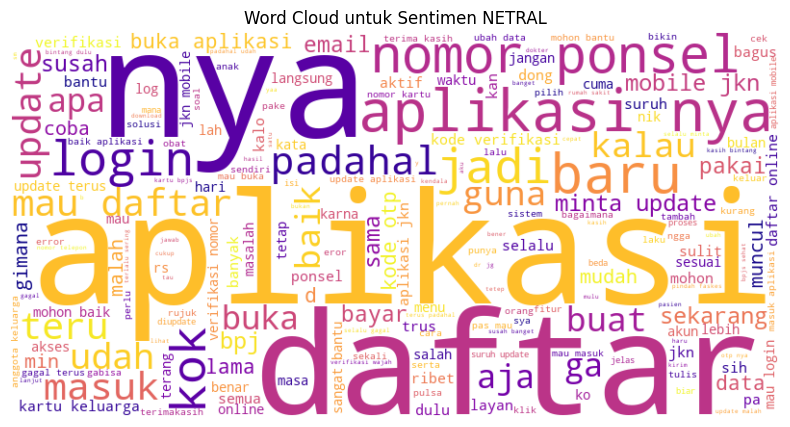


Periksa setiap word cloud. Apakah kata-kata yang muncul sudah sesuai dengan sentimennya? Jika kata 'error' muncul besar di word cloud positif, itu tandanya ada masalah.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import ast # Untuk mengubah string list menjadi list sungguhan

print("--- Memulai Skrip Analisis Kualitas Data ---")

try:
    # 1. Muat data yang sudah melalui semua tahap pra-pemrosesan
    df = pd.read_csv("hasil_bersih35ribu.csv")
    print("Data hasil pra-pemrosesan berhasil dimuat.")
    
    # PERUBAHAN: Menyesuaikan nama kolom sesuai data Anda
    # Kolom yang berisi token yang sudah bersih adalah 'stemmed_tokens'
    # Kolom label adalah 'Label'
    target_token_col = 'stemmed_tokens'
    target_label_col = 'Label'

    # Pastikan kolom-kolom yang dibutuhkan ada
    if target_token_col not in df.columns or target_label_col not in df.columns:
        raise KeyError(f"Pastikan file CSV memiliki kolom '{target_token_col}' dan '{target_label_col}'.")

    # --- Metode 1: Analisis Frekuensi Kata (Top 30) ---
    print("\n--- Analisis Frekuensi Kata (Top 30 Teratas) ---")
    
    # Mengubah string list dari kolom target menjadi list sungguhan
    # dan menggabungkan semua token menjadi satu daftar besar
    all_tokens = []
    # Menggunakan .dropna() untuk menghindari error jika ada baris kosong
    df[target_token_col].dropna().apply(lambda tokens_str: all_tokens.extend(ast.literal_eval(tokens_str)))

    # Menghitung frekuensi setiap kata
    word_freq = Counter(all_tokens)
    
    # Mengambil 30 kata paling umum
    common_words = word_freq.most_common(30)
    
    # Membuat DataFrame untuk visualisasi
    df_common_words = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])
    
    # Membuat plot batang
    plt.figure(figsize=(12, 10))
    sns.barplot(x='Frekuensi', y='Kata', data=df_common_words, palette='viridis')
    plt.title('Top 30 Kata yang Paling Sering Muncul di Seluruh Ulasan')
    plt.xlabel('Frekuensi Kemunculan')
    plt.ylabel('Kata')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("\nPeriksa daftar di atas. Apakah ada stopwords (e.g., 'yg', 'di'), typo, atau kata tidak relevan? Jika ada, data Anda perlu pembersihan lebih lanjut.")

    # --- Metode 2: Visualisasi dengan Word Cloud per Sentimen ---
    print("\n--- Analisis Word Cloud per Kategori Sentimen ---")
    
    # Fungsi untuk membuat dan menampilkan word cloud
    def generate_wordcloud(data, title):
        # Menggabungkan semua token menjadi satu string panjang
        text = ' '.join(word for tokens_list in data for word in tokens_list)
        if not text:
            print(f"Tidak ada data untuk word cloud '{title}'.")
            return
            
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(title)
        plt.show()

    # Membuat kolom baru berisi list token (untuk menghindari pemanggilan ast.literal_eval berulang kali)
    df['tokens_list'] = df[target_token_col].dropna().apply(ast.literal_eval)
    
    # Pisahkan data berdasarkan label sentimen
    positif_tokens = df[df[target_label_col] == 'Positif']['tokens_list']
    negatif_tokens = df[df[target_label_col] == 'Negatif']['tokens_list']
    netral_tokens = df[df[target_label_col] == 'Netral']['tokens_list']

    # Generate word cloud untuk setiap sentimen
    generate_wordcloud(positif_tokens, 'Word Cloud untuk Sentimen POSITIF')
    generate_wordcloud(negatif_tokens, 'Word Cloud untuk Sentimen NEGATIF')
    generate_wordcloud(netral_tokens, 'Word Cloud untuk Sentimen NETRAL')

    print("\nPeriksa setiap word cloud. Apakah kata-kata yang muncul sudah sesuai dengan sentimennya? Jika kata 'error' muncul besar di word cloud positif, itu tandanya ada masalah.")


except FileNotFoundError:
    print("Error: File 'hasil_akhir_preprocessing20ribu.csv' tidak ditemukan. Pastikan Anda sudah menjalankan semua skrip pra-pemrosesan sebelumnya.")
except KeyError as e:
    print(f"Error pada kolom: {e}. Pastikan nama kolom di file CSV Anda sudah benar.")
except Exception as e:
    print(f"Terjadi error tak terduga: {e}")


In [1]:
# ==============================================================================
# TAHAP ML-B (VARIAN MWMOTE/BORDERLINE): BALANCING TERKONTROL
# Tugas: Menyeimbangkan data dengan fokus pada sampel yang 'sulit' (Borderline)
#        menggunakan pendekatan weighted mirip MWMOTE.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import pickle
from collections import Counter
import time
import sys

from sklearn.model_selection import train_test_split
# GANTI: Pakai BorderlineSMOTE untuk meniru perilaku MWMOTE (fokus ke data sulit)
from imblearn.over_sampling import BorderlineSMOTE 
from imblearn.under_sampling import RandomUnderSampler

# ==============================================================================
# 2. KONFIGURASI FILE & UKURAN
# ==============================================================================
# Input file (Pastikan ini file .pkl hasil TF-IDF yang sama dengan sebelumnya)
INPUT_DATA_FILE = "data_untuk_model.pkl" 

# GANTI: Nama file output dibedakan agar tidak tertukar
OUTPUT_DATA_FILE = "final_data_mwmote.pkl"

# --- Konfigurasi Balancing ---
TARGET_SAMPLES_PER_CLASS = 20000 

# --- Konfigurasi Split Data ---
TEST_SIZE_PERCENTAGE = 0.2
RANDOM_STATE_SEED = 42

# ==============================================================================
# 3. PROSES UTAMA
# ==============================================================================
def run_mwmote_balancing_pipeline():
    """
    Alur kerja balancing menggunakan pendekatan Borderline (MWMOTE-style).
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai proses Split Data & Balancing (Metode Borderline/MWMOTE)...")
        
        # --- Memuat Data Hasil TF-IDF ---
        print(f"🔄 Memuat data dari '{INPUT_DATA_FILE}'...")
        with open(INPUT_DATA_FILE, 'rb') as f:
            processed_data = pickle.load(f)
    
        X_original = processed_data['matrix']
        y_original = processed_data['labels']
        vectorizer = processed_data['vectorizer']
        print("✅ Data sumber berhasil dimuat.")

        # --- Langkah 1: Train/Test Split ---
        print("\n🔄 Memisahkan data menjadi data latih dan data uji...")
        X_train, X_test, y_train, y_test = train_test_split(
            X_original, y_original, test_size=TEST_SIZE_PERCENTAGE, 
            random_state=RANDOM_STATE_SEED, stratify=y_original
        )
        print("✅ Data berhasil dipisah.")
        print(f"   - Ukuran Data Latih: {X_train.shape[0]} sampel")
        print(f"   - Ukuran Data Uji:   {X_test.shape[0]} sampel")
        
        print("\n📊 Distribusi kelas SEBELUM Balancing:")
        print(Counter(y_train))

        # --- Langkah 2: Over-sampling (MWMOTE Style / Borderline) ---
        print(f"\n🔄 Tahap Balancing 1 (Borderline-SMOTE): Fokus pada data Netral yang sulit...")
        
        n_netral_in_train = Counter(y_train).get('Netral', 0)
        # Menjaga agar k_neighbors tidak error jika data sangat sedikit
        k_neighbors_val = min(5, n_netral_in_train - 1) if n_netral_in_train > 1 else 1

        # Kita hanya menargetkan kelas 'Netral'
        over_sampling_strategy = {'Netral': TARGET_SAMPLES_PER_CLASS}
        
        # PENGGUNAAN BORDERLINE SMOTE
        # kind='borderline-1' adalah metode yang paling mendekati MWMOTE
        # Dia mendeteksi sampel di perbatasan (border) dan melakukan oversampling di sana.
        over_sampler = BorderlineSMOTE(
            sampling_strategy=over_sampling_strategy,
            random_state=RANDOM_STATE_SEED,
            k_neighbors=k_neighbors_val,
            kind='borderline-1' 
        )
        
        # Proses fitting mungkin agak lebih lama dari SMOTE biasa karena ada perhitungan jarak
        X_intermediate, y_intermediate = over_sampler.fit_resample(X_train, y_train)
        print("   - Distribusi setelah Borderline-SMOTE:", Counter(y_intermediate))

        # --- Langkah 3: Under-sampling (Menurunkan Mayoritas) ---
        print(f"\n🔄 Tahap Balancing 2 (Random Under-sampling): Menurunkan mayoritas...")
        
        under_sampling_strategy = {
            'Negatif': TARGET_SAMPLES_PER_CLASS, 
            'Positif': TARGET_SAMPLES_PER_CLASS
        }
        
        under_sampler = RandomUnderSampler(
            sampling_strategy=under_sampling_strategy,
            random_state=RANDOM_STATE_SEED
        )
        X_train_resampled, y_train_resampled = under_sampler.fit_resample(X_intermediate, y_intermediate)

        # --- Hasil Akhir ---
        print("\n✅ Proses balancing selesai.")
        print("\n📊 Distribusi kelas SETELAH Balancing Final:")
        print(Counter(y_train_resampled))
        print(f"(Total data latih sekarang: {len(y_train_resampled)} baris)")

        # --- Mempersiapkan dan Menyimpan Paket Data Final ---
        final_data_package = {
            'X_train_balanced': X_train_resampled,
            'y_train_balanced': y_train_resampled,
            'X_test_original': X_test,
            'y_test_original': y_test,
            'vectorizer': vectorizer
        }
        
        print(f"\n💾 Menyimpan data ke file BARU: '{OUTPUT_DATA_FILE}'...")
        with open(OUTPUT_DATA_FILE, 'wb') as f:
            pickle.dump(final_data_package, f)
    
        end_time = time.time()
        print(f"\n🎉 Selesai! File '{OUTPUT_DATA_FILE}' siap dipakai untuk training.")

    except Exception as e:
        print(f"❌ Error: {e}")
        sys.exit()

# ==============================================================================
# 4. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    run_mwmote_balancing_pipeline()

▶️  Memulai proses Split Data & Balancing (Metode Borderline/MWMOTE)...
🔄 Memuat data dari 'data_untuk_model.pkl'...
✅ Data sumber berhasil dimuat.

🔄 Memisahkan data menjadi data latih dan data uji...
✅ Data berhasil dipisah.
   - Ukuran Data Latih: 132555 sampel
   - Ukuran Data Uji:   33139 sampel

📊 Distribusi kelas SEBELUM Balancing:
Counter({'Negatif': 79854, 'Positif': 51851, 'Netral': 850})

🔄 Tahap Balancing 1 (Borderline-SMOTE): Fokus pada data Netral yang sulit...
   - Distribusi setelah Borderline-SMOTE: Counter({'Negatif': 79854, 'Positif': 51851, 'Netral': 20000})

🔄 Tahap Balancing 2 (Random Under-sampling): Menurunkan mayoritas...

✅ Proses balancing selesai.

📊 Distribusi kelas SETELAH Balancing Final:
Counter({'Negatif': 20000, 'Netral': 20000, 'Positif': 20000})
(Total data latih sekarang: 60000 baris)

💾 Menyimpan data ke file BARU: 'final_data_mwmote.pkl'...

🎉 Selesai! File 'final_data_mwmote.pkl' siap dipakai untuk training.


In [2]:
# ==============================================================================
# TAHAP AKHIR (ML-C): PELATIHAN MODEL (VARIAN MWMOTE/BORDERLINE)
# Tugas: Melatih Random Forest pada data "final_data_mwmote.pkl",
#        dan menyimpan hasil dengan nama file KHUSUS agar tidak menimpa yang lama.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import pickle
import joblib 
import json
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)

# ==============================================================================
# 2. KONFIGURASI NAMA FILE (SUDAH DIBEDAKAN)
# ==============================================================================
# INPUT: Wajib sama dengan output dari skrip balancing terakhir
INPUT_DATA_FILE = "final_data_mwmote.pkl"

# OUTPUT: Nama file saya kasih akhiran '_mwmote' biar beda dari yang lama
OUTPUT_MODEL_FILE = "model_rf_mwmote_final.joblib"       # Model khusus MWMOTE
OUTPUT_VECTORIZER_FILE = "vectorizer_mwmote_final.joblib" # Vectorizer pasangannya
OUTPUT_EVALUATION_FILE = "hasil_evaluasi_mwmote.json"     # Hasil skornya

# ==============================================================================
# 3. PROSES PELATIHAN DAN EVALUASI
# ==============================================================================
def train_and_evaluate_final_model():
    """
    Fungsi utama untuk memuat data MWMOTE, melatih model, dan simpan aset baru.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap Final: Pelatihan Model (Varian MWMOTE)...")

        # --- Memuat Data ---
        print(f"🔄 Memuat data dari '{INPUT_DATA_FILE}'...")
        try:
            with open(INPUT_DATA_FILE, 'rb') as f:
                data = pickle.load(f)
        except FileNotFoundError:
            print(f"❌ ERROR: File '{INPUT_DATA_FILE}' tidak ditemukan!")
            print("   Jalankan dulu skrip balancing (Tahap ML-B) yang baru.")
            sys.exit()

        X_train = data['X_train_balanced']
        y_train = data['y_train_balanced']
        X_test = data['X_test_original']
        y_test = data['y_test_original']
        vectorizer = data['vectorizer']
        print("✅ Data MWMOTE berhasil dimuat.")

        # --- Konfigurasi Model ---
        print("\n🛠️  Mengonfigurasi Grid Search Random Forest...")
        
        rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

        # Parameter yang akan dicoba (Bisa ditambah jika PC kuat)
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [None, 30, 50],
            'min_samples_leaf': [1, 2],
            'min_samples_split': [2, 5]
        }
        
        grid_search = GridSearchCV(
            estimator=rf_model,
            param_grid=param_grid,
            cv=3,       
            n_jobs=-1,  
            verbose=2, 
            scoring='f1_weighted'
        )

        # --- Melatih Model ---
        print(f"\n🏃 Training dimulai pada {len(y_train)} data latih... (Sabar ya)")
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        print("\n🏆 Training Selesai! Parameter terbaik:")
        print(grid_search.best_params_)

        # --- Evaluasi ---
        print(f"\n🔬 Menguji model pada data test...")
        y_pred = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("\n" + "="*50)
        print("📊 HASIL EVALUASI (MWMOTE VERSION)")
        print("="*50)
        print(f"   - Akurasi   : {accuracy:.2%}")
        print(f"   - F1-Score  : {f1:.2%}")
        print("\nDetail per kelas:")
        print(classification_report(y_test, y_pred))

        # --- Simpan Hasil ---
        report_dict = classification_report(y_test, y_pred, output_dict=True)
        cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
        
        evaluation_results = {
            'metode_balancing': 'Borderline-SMOTE (MWMOTE)',
            'akurasi': f"{accuracy:.2%}",
            'f1_score': f"{f1:.2%}",
            'classification_report': report_dict,
            'best_params': grid_search.best_params_,
            'confusion_matrix': cm.tolist(),
            'classes': best_model.classes_.tolist()
        }

        print(f"\n💾 Menyimpan file output (Nama BEDA dari sebelumnya)...")
        
        # Simpan Model
        joblib.dump(best_model, OUTPUT_MODEL_FILE)
        print(f"   - ✅ Model baru: '{OUTPUT_MODEL_FILE}'")
        
        # Simpan Vectorizer
        joblib.dump(vectorizer, OUTPUT_VECTORIZER_FILE)
        print(f"   - ✅ Vectorizer baru: '{OUTPUT_VECTORIZER_FILE}'")
        
        # Simpan JSON Evaluasi
        with open(OUTPUT_EVALUATION_FILE, 'w') as f_json:
            json.dump(evaluation_results, f_json, indent=4)
        print(f"   - ✅ Laporan evaluasi: '{OUTPUT_EVALUATION_FILE}'")
        
        end_time = time.time()
        print(f"\n🎉 SELESAI! Waktu total: {int(end_time - start_time)} detik.")
        
    except Exception as e:
        print(f"❌ Error tak terduga: {e}")
        sys.exit()

if __name__ == "__main__":
    train_and_evaluate_final_model()

▶️  Memulai Tahap Final: Pelatihan Model (Varian MWMOTE)...
🔄 Memuat data dari 'final_data_mwmote.pkl'...
✅ Data MWMOTE berhasil dimuat.

🛠️  Mengonfigurasi Grid Search Random Forest...

🏃 Training dimulai pada 60000 data latih... (Sabar ya)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

🏆 Training Selesai! Parameter terbaik:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

🔬 Menguji model pada data test...

📊 HASIL EVALUASI (MWMOTE VERSION)
   - Akurasi   : 87.43%
   - F1-Score  : 87.43%

Detail per kelas:
              precision    recall  f1-score   support

     Negatif       0.89      0.92      0.90     19963
      Netral       0.03      0.04      0.03       213
     Positif       0.86      0.82      0.84     12963

    accuracy                           0.87     33139
   macro avg       0.59      0.59      0.59     33139
weighted avg       0.87      0.87      0.87     33139


💾 Menyimpan file output (Nama BEDA dari sebelumnya